In [2]:
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import geneinfo.information as gi
from geneinfo.genelist import GeneList as glist
from vscodenb import set_vscode_theme, pqdm, prange, truncate_colormap, Left
from vscodenb import vscode_theme as theme
from jscatter import Scatter
set_vscode_theme('dark')
%config InlineBackend.figure_formats = ['svg'] 

In [3]:


# display(HTML('''
# <style>
#   .widget-output { background-color: #1e1e1e !important; button_color: #1e1e1e !important; }
#   .jp-OutputArea-output { background-color: #1e1e1e !important; }

             
             
# .cell-output-ipywidget-background {
#     background-color: transparent !important;
# }
# :root {
#     --jp-widgets-color: var(--vscode-editor-foreground);
#     --jp-widgets-font-size: var(--vscode-editor-font-size);
# }  

             
             
# .jp-OutputArea-output {
#    background-color: transparent;
# }  
             
# .jupyter-matplotlib {
#     background-color: #000000;
# }

# .widget-label, .jupyter-matplotlib-header{
#     color: #fff;
# }

# .jupyter-button {
#     background-color: #333333;
#     color: #ffffff;
# }             
             
# </style>
# '''))


In [4]:
chromosomes = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

populations = [
        'CHB', 'JPT', 'CHS', 'CDX', 'KHV', #'CHD', 
        'CEU', 'TSI', 'GBR', 'FIN', 'IBS', 
        'YRI', 'LWK', 'GWD', 'MSL', 'ESN', 
        'ASW', 'ACB', 'MXL', 'PUR', 'CLM', 'PEL', 
        'GIH', 'PJL', 'BEB', 'STU', 'ITU'
        ]
region_pops = {
    'EastAsia': ['CHB', 'JPT', 'CHS', 'CDX', 'KHV'],
    'Europe': ['CEU', 'TSI', 'GBR', 'FIN', 'IBS'], 
    'Africa': ['YRI', 'LWK', 'GWD', 'MSL', 'ESN'], 
    'America': ['ASW', 'ACB', 'MXL', 'PUR', 'CLM', 'PEL'], 
    'SouthAsia': ['GIH', 'PJL', 'BEB', 'STU', 'ITU']
}
regions = {pop: region for region, pops in region_pops.items() for pop in pops}

In [5]:
all_variants_human = pd.read_csv('../results/all_variants_human_gnomad.csv', dtype={'chromosome': str})
all_variants_human['chromosome'] = ['chr' + chrom for chrom in all_variants_human.chromosome]
all_variants_human['chromosome'] = pd.Categorical(all_variants_human.chromosome, categories=chromosomes, ordered=True)
all_variants_human.rename(columns={'chromosome': 'chrom', 'genomic_position': 'pos', 'allele_frequency': 'af', 'gene_name': 'gene'}, inplace=True)
all_variants_human.columns, all_variants_human.shape

(Index(['species', 'gene_id', 'gene', 'transcript_id', 'variant_id', 'rsid',
        'chrom', 'pos', 'ref_allele', 'alt_allele', 'aa_position', 'ref_aa',
        'alt_aa', 'hgvsp', 'hgvsc', 'consequence', 'af', 'exome_af',
        'genome_af', 'exome_ac', 'exome_an', 'exome_ac_hom', 'exome_ac_hemi',
        'genome_ac', 'genome_an', 'genome_ac_hom', 'genome_ac_hemi',
        'faf95_max', 'faf95_max_population', 'faf99_max',
        'faf99_max_population', 'faf95_popmax', 'faf95_popmax_population',
        'af_afr', 'af_amr', 'af_asj', 'af_eas', 'af_fin', 'af_nfe', 'af_sas',
        'af_mid', 'af_ami', 'cadd_phred', 'revel_score', 'spliceai_score',
        'alphamissense_score', 'pangolin_score', 'phylop_score', 'sift_max',
        'polyphen_max', 'polyphen_prediction', 'sift_prediction', 'lof',
        'lof_filter', 'lof_flags', 'flags', 'exome_filters', 'genome_filters',
        'source'],
       dtype='object'),
 (18649, 59))

::: {.callout-note}

## TODO

- Ask Vasili about non-human variants from Kyle's dataset
- Does the relationship between selection and pathogenicity differ for across the genome, or for genes with and without expression in spermatids?
- why are all all_variants_human.lof nan?

:::

In [6]:
assert all_variants_human.gene_id.nunique() == all_variants_human.transcript_id.nunique()

In [7]:
relate_df = pd.read_parquet('/home/kmt/xy-drive/people/kmt/relate1Kgenomes/notebooks/all_pops_sele.parquet')
relate_df['when_DAF_is_half'] *= -1
relate_df['when_mutation_has_freq2'] *= -1
relate_df

,chrom,pos,rs_id,variant_id,pop,when_DAF_is_half,when_mutation_has_freq2
0,chr1,817341,1:817341:A:G,1-817341-A-G,CHS,2.102790,6.24528
1,chr1,819123,1:819123:G:A,1-819123-G-A,CHS,2.102790,6.24528
2,chr1,819123,1:819123:G:A,1-819123-G-A,MXL,2.630620,4.96580
3,chr1,849670,1:849670:G:A,1-849670-G-A,CHS,1.607340,5.42580
4,chr1,855085,1:855085:G:A,1-855085-G-A,YRI,2.101570,5.25291
...,...,...,...,...,...,...,...
106512,chrX,155999338,X:155999338:G:A,X-155999338-G-A,LWK,1.402060,6.64413
106513,chrX,155999435,X:155999435:C:G,X-155999435-C-G,ACB,0.995721,5.91133
106514,chrX,155999524,X:155999524:T:C,X-155999524-T-C,LWK,0.973655,5.00594
106515,chrX,155999818,X:155999818:C:T,X-155999818-C-T,GWD,0.301155,6.70790


In [8]:
relate_df_wide = relate_df[['variant_id', 'pop', 'when_mutation_has_freq2']].pivot(index='variant_id', columns='pop', values='when_mutation_has_freq2')
relate_df_wide.head()

pop,ACB,ASW,BEB,CDX,CEU,CHB,CHS,CLM,ESN,FIN,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
variant_id,,,,,,,,,,,,,,,,,,,,,
1-100007048-A-G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1-100007871-T-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1-100011106-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1-100017453-C-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.4539,NaN,NaN,NaN,NaN,NaN,NaN
1-100018266-A-G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.4539,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# cols = ['variant_id', 'gene', 'chrom', 'pos', 'af', 'cadd_phred', 'revel_score'] 
cols = all_variants_human.columns
cols

Index(['species', 'gene_id', 'gene', 'transcript_id', 'variant_id', 'rsid',
       'chrom', 'pos', 'ref_allele', 'alt_allele', 'aa_position', 'ref_aa',
       'alt_aa', 'hgvsp', 'hgvsc', 'consequence', 'af', 'exome_af',
       'genome_af', 'exome_ac', 'exome_an', 'exome_ac_hom', 'exome_ac_hemi',
       'genome_ac', 'genome_an', 'genome_ac_hom', 'genome_ac_hemi',
       'faf95_max', 'faf95_max_population', 'faf99_max',
       'faf99_max_population', 'faf95_popmax', 'faf95_popmax_population',
       'af_afr', 'af_amr', 'af_asj', 'af_eas', 'af_fin', 'af_nfe', 'af_sas',
       'af_mid', 'af_ami', 'cadd_phred', 'revel_score', 'spliceai_score',
       'alphamissense_score', 'pangolin_score', 'phylop_score', 'sift_max',
       'polyphen_max', 'polyphen_prediction', 'sift_prediction', 'lof',
       'lof_filter', 'lof_flags', 'flags', 'exome_filters', 'genome_filters',
       'source'],
      dtype='object')

In [10]:

hum_var = (
    all_variants_human
    .merge(relate_df_wide.reset_index(), left_on='variant_id', right_on='variant_id', how='left')
    )
hum_var.drop(columns=['sift_prediction', 'lof_flags', 'lof_filter', 'lof', 'exome_filters', 
                      'genome_filters', 'polyphen_prediction', 'source', 'gene_id', 'transcript_id', 'alphamissense_score'], inplace=True)
hum_var.head()

,species,gene,variant_id,rsid,chrom,pos,ref_allele,alt_allele,aa_position,ref_aa,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
0,human,DHRSX,X-2221145-C-T,rs12010,chrX,2221145,C,T,297,Glu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,human,DHRSX,X-2221159-T-C,rs3210910,chrX,2221159,T,C,292,His,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,human,DHRSX,X-2243088-C-G,rs1127915,chrX,2243088,C,G,247,Val,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,human,CRLF2,X-1193297-T-C,rs1348007359,chrX,1193297,T,C,258,Lys,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,human,ASMT,X-1632709-T-C,rs6588809,chrX,1632709,T,C,190,Trp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
plot_df = hum_var.melt(id_vars=[x for x in hum_var.columns if x not in populations],
                       value_vars=populations, var_name='pop', value_name='relate_p')
plot_df['region'] = pd.Categorical([regions[p] for p in plot_df['pop']], ordered=True, categories=['Africa', 'Europe', 'SouthAsia', 'EastAsia', 'America'])
plot_df.head()

,species,gene,variant_id,rsid,chrom,pos,ref_allele,alt_allele,aa_position,ref_aa,...,revel_score,spliceai_score,pangolin_score,phylop_score,sift_max,polyphen_max,flags,pop,relate_p,region
0,human,DHRSX,X-2221145-C-T,rs12010,chrX,2221145,C,T,297,Glu,...,0.117,0.00,0.00,5.800,0.17,0.161,par,CHB,NaN,EastAsia
1,human,DHRSX,X-2221159-T-C,rs3210910,chrX,2221159,T,C,292,His,...,0.109,0.00,0.01,0.654,0.81,0.000,par,CHB,NaN,EastAsia
2,human,DHRSX,X-2243088-C-G,rs1127915,chrX,2243088,C,G,247,Val,...,0.189,0.00,0.00,3.830,1.00,0.000,par,CHB,NaN,EastAsia
3,human,CRLF2,X-1193297-T-C,rs1348007359,chrX,1193297,T,C,258,Lys,...,NaN,NaN,-0.05,0.111,0.06,0.985,par,CHB,NaN,EastAsia
4,human,ASMT,X-1632709-T-C,rs6588809,chrX,1632709,T,C,190,Trp,...,0.023,0.05,0.01,0.132,0.32,0.000,par,CHB,NaN,EastAsia


In [12]:
from ipywidgets import Layout, HBox, Output

df = hum_var#[['gene', 'chrom', 'af', 'cadd_phred', 'revel_score']]


In [13]:
hum_var.columns

Index(['species', 'gene', 'variant_id', 'rsid', 'chrom', 'pos', 'ref_allele',
       'alt_allele', 'aa_position', 'ref_aa', 'alt_aa', 'hgvsp', 'hgvsc',
       'consequence', 'af', 'exome_af', 'genome_af', 'exome_ac', 'exome_an',
       'exome_ac_hom', 'exome_ac_hemi', 'genome_ac', 'genome_an',
       'genome_ac_hom', 'genome_ac_hemi', 'faf95_max', 'faf95_max_population',
       'faf99_max', 'faf99_max_population', 'faf95_popmax',
       'faf95_popmax_population', 'af_afr', 'af_amr', 'af_asj', 'af_eas',
       'af_fin', 'af_nfe', 'af_sas', 'af_mid', 'af_ami', 'cadd_phred',
       'revel_score', 'spliceai_score', 'pangolin_score', 'phylop_score',
       'sift_max', 'polyphen_max', 'flags', 'ACB', 'ASW', 'BEB', 'CDX', 'CEU',
       'CHB', 'CHS', 'CLM', 'ESN', 'FIN', 'GBR', 'GIH', 'GWD', 'IBS', 'ITU',
       'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL', 'PUR', 'STU', 'TSI',
       'YRI'],
      dtype='object')

In [14]:
#d = dict(x="af", y="revel_score", color="cadd_phred", size="relate_p", opacity="relate_p")
d = dict(x="af", y="revel_score", color="cadd_phred", size="relate_p", opacity="relate_p")

scatter = Scatter(data=plot_df, x=d["x"], y=d["y"], height=500, width=500, legend=True)
scatter.axes(labels=[d["x"], d["y"]])
scatter.color(by=d["color"], map="viridis")     #, labeling={"variable": "p-value", "minValue": "significant", "maxValue": "insignificant"})
#scatter.opacity(by=d["opacity"])
#scatter.size(by=d["size"])
scatter.background('#1e1e1e')
# scatter.tooltip(True,  properties=["af", "cadd_phred", "chrom", 'gene'])
# scatter.tooltip(True, properties=plot_df.columns.tolist())
scatter.show()

output = Output()

@output.capture(clear_output=True)
def selection_change_handler(change):
    display(df.loc[change.new].style.hide(axis='index'))
            
scatter.widget.observe(selection_change_handler, names=["selection"])

HBox([scatter.show(), output], layout=Layout(margin='10px 0 0 0'))

/home/kmt/xy-drive/people/kmt/primate-prot-var/.pixi/envs/default/lib/python3.12/site-packages/jscatter/utils.py:387: UserWarning: Y data contains missing values. Those missing values will be replaced with zeros.
  warnings.warn(


In [15]:
plot_df

,species,gene,variant_id,rsid,chrom,pos,ref_allele,alt_allele,aa_position,ref_aa,...,revel_score,spliceai_score,pangolin_score,phylop_score,sift_max,polyphen_max,flags,pop,relate_p,region
0,human,DHRSX,X-2221145-C-T,rs12010,chrX,2221145,C,T,297,Glu,...,0.117,0.00,0.00,5.800,0.17,0.161,par,CHB,NaN,EastAsia
1,human,DHRSX,X-2221159-T-C,rs3210910,chrX,2221159,T,C,292,His,...,0.109,0.00,0.01,0.654,0.81,0.000,par,CHB,NaN,EastAsia
2,human,DHRSX,X-2243088-C-G,rs1127915,chrX,2243088,C,G,247,Val,...,0.189,0.00,0.00,3.830,1.00,0.000,par,CHB,NaN,EastAsia
3,human,CRLF2,X-1193297-T-C,rs1348007359,chrX,1193297,T,C,258,Lys,...,0.000,NaN,-0.05,0.111,0.06,0.985,par,CHB,NaN,EastAsia
4,human,ASMT,X-1632709-T-C,rs6588809,chrX,1632709,T,C,190,Trp,...,0.023,0.05,0.01,0.132,0.32,0.000,par,CHB,NaN,EastAsia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484869,human,IQCG,3-197932289-C-G,rs67877771,chr3,197932289,C,G,177,Asp,...,0.201,0.00,-0.01,2.900,0.01,0.948,NaN,ITU,NaN,SouthAsia
484870,human,IQCG,3-197938728-G-T,rs9880989,chr3,197938728,G,T,112,Ala,...,0.103,0.18,0.01,-0.711,0.61,0.093,NaN,ITU,NaN,SouthAsia
484871,human,TNK2,3-195868079-G-A,rs56260729,chr3,195868079,G,A,740,Pro,...,0.000,0.00,0.00,0.501,0.48,0.000,NaN,ITU,NaN,SouthAsia
484872,human,FYTTD1,3-197768463-G-A,rs3205525,chr3,197768463,G,A,87,Arg,...,0.085,0.00,0.00,1.930,0.09,0.022,NaN,ITU,NaN,SouthAsia


In [16]:
import jscatter

# facets = [
#     dict(x="af", y="cadd_phred", color="cadd_phred", opacity="cadd_phred", size="cadd_phred"),
#     dict(x="af", y="revel_score", color="revel_score", opacity="cadd_phred", size="cadd_phred"),
#     dict(x="af", y="cadd_phred", color="revel_score", opacity="cadd_phred", size="cadd_phred"),
#     dict(x="af", y="cadd_phred", color="revel_score", opacity="cadd_phred", size="cadd_phred"),
#     dict(x="af", y="cadd_phred", color="revel_score", opacity="cadd_phred", size="cadd_phred"),
#     dict(x="af", y="cadd_phred", color="revel_score", opacity="cadd_phred", size="cadd_phred"),
# ]

facets = [dict(x=f"af", y="cadd_phred", color="revel_score", size=pop) for pop in region_pops['Africa']]


subplots = []
for d in facets:
    scatter = Scatter(data=hum_var, x=d["x"], y=d["y"], height=40, legend=True)
    scatter.axes(labels=[d["x"], d["y"]])
    scatter.color(by=d["color"], map="viridis") #, labeling={"variable": "p-value", "minValue": "significant", "maxValue": "insignificant"})
    # scatter.opacity(by=d["opacity"])
    scatter.size(by=d["size"])
    scatter.background('#1e1e1e')
    # scatter.tooltip(True,  properties=["af", "cadd_phred", "chrom", 'gene'])
    scatter.tooltip(True, properties=df.columns.tolist())
    # scatter.tooltip(True, properties=df.columns.tolist(), preview="variant_id", preview_type="text", histograms_size="large")
    scatter.show()

    subplots.append(scatter)

jscatter.compose(
    subplots,
    sync_selection=True,
    sync_hover=True,
    cols=3
)


/home/kmt/xy-drive/people/kmt/primate-prot-var/.pixi/envs/default/lib/python3.12/site-packages/jscatter/utils.py:387: UserWarning: Color data contains missing values. Those missing values will be replaced with zeros.
  warnings.warn(
/home/kmt/xy-drive/people/kmt/primate-prot-var/.pixi/envs/default/lib/python3.12/site-packages/jscatter/utils.py:387: UserWarning: Size data contains missing values. Those missing values will be replaced with zeros.
  warnings.warn(
/home/kmt/xy-drive/people/kmt/primate-prot-var/.pixi/envs/default/lib/python3.12/site-packages/jscatter/utils.py:356: RuntimeWarning: invalid value encountered in divide
  return list(hist[0] / hist[0].max())
/home/kmt/xy-drive/people/kmt/primate-prot-var/.pixi/envs/default/lib/python3.12/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON

GridBox(children=(VBox(children=(HBox(children=(VBox(children=(<jscatter.widgets.button.Button object at 0x7ff…

In [18]:

# scatter = Scatter(x='x', y='y', color_by='c', size=5, data=df, width=500, height=500)
# scatter.tooltip(True)
# scatter.background('#1e1e1e')


In [19]:

df = pd.read_parquet('cities.pq')
df.drop_duplicates(subset=['Name'], inplace=True) # names must be unique to each continent
df.reset_index(inplace=True)

from jscatter import Scatter, LabelPlacement

kwargs = dict(
    tooltip=True,
    tooltip_properties=df.columns.tolist(),
    tooltip_preview="Name",
    tooltip_preview_type="text",
    tooltip_histograms_size="large",      
    axes=False,
    legend=True,
    height=1000,
    background_color='#1E1E20', 
)

In [20]:
label_placement = LabelPlacement(
    data=df,
    by=['Continent', 'Name'],
    x='Mercator X',
    y='Mercator Y',
    # positioning='center_of_mass',
    importance='Population', 
    importance_aggregation='max',
    hierarchical=True,
)
label_df = label_placement.compute(show_progress=True)

Compute labels:   0%|          | 0/517025 [Total: 00:00]

In [21]:
scatter = Scatter(
    data=df,
    x='Mercator X',
    y='Mercator Y',
   color_by='Continent', 
   size_by='Population', #size_map=(5, 15, 5),
    **kwargs
)
scatter.label(color='#f6f6f6', using=label_placement)
scatter.show()

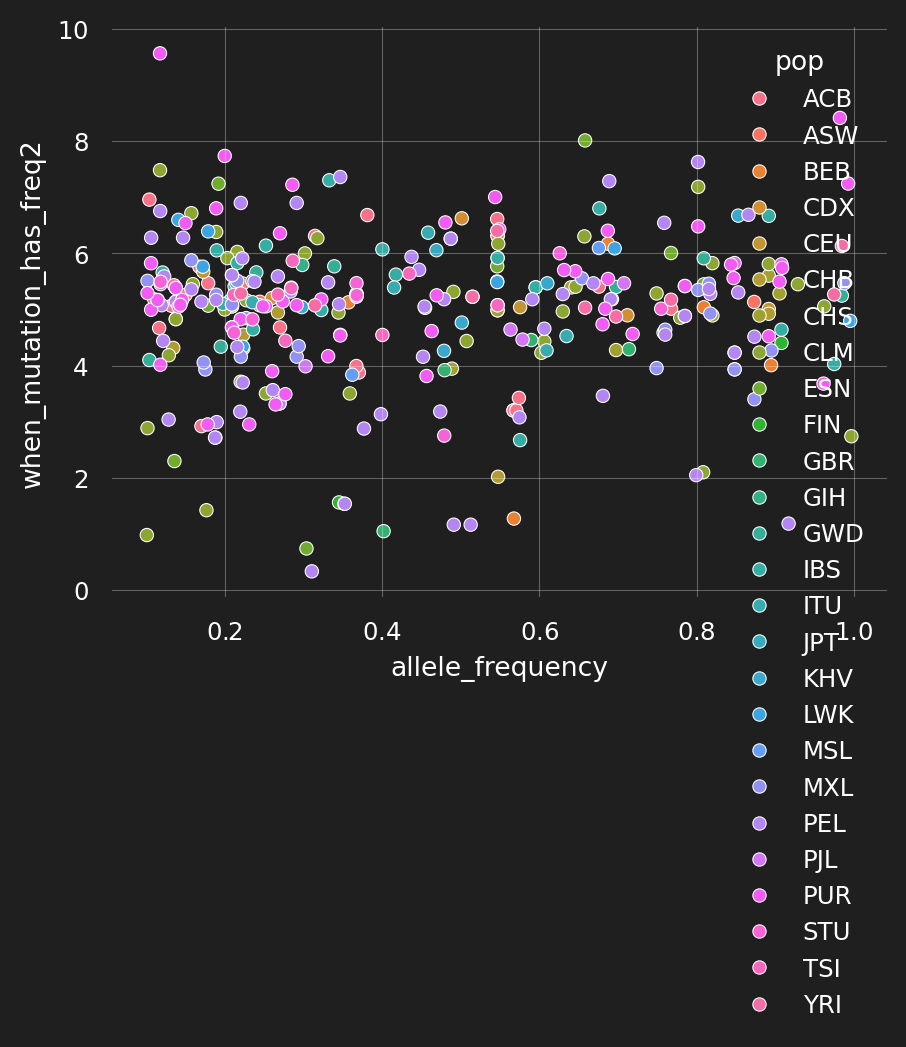

In [ ]:
sns.scatterplot(plot_df, x='af', y='when_mutation_has_freq2', hue='pop') ;


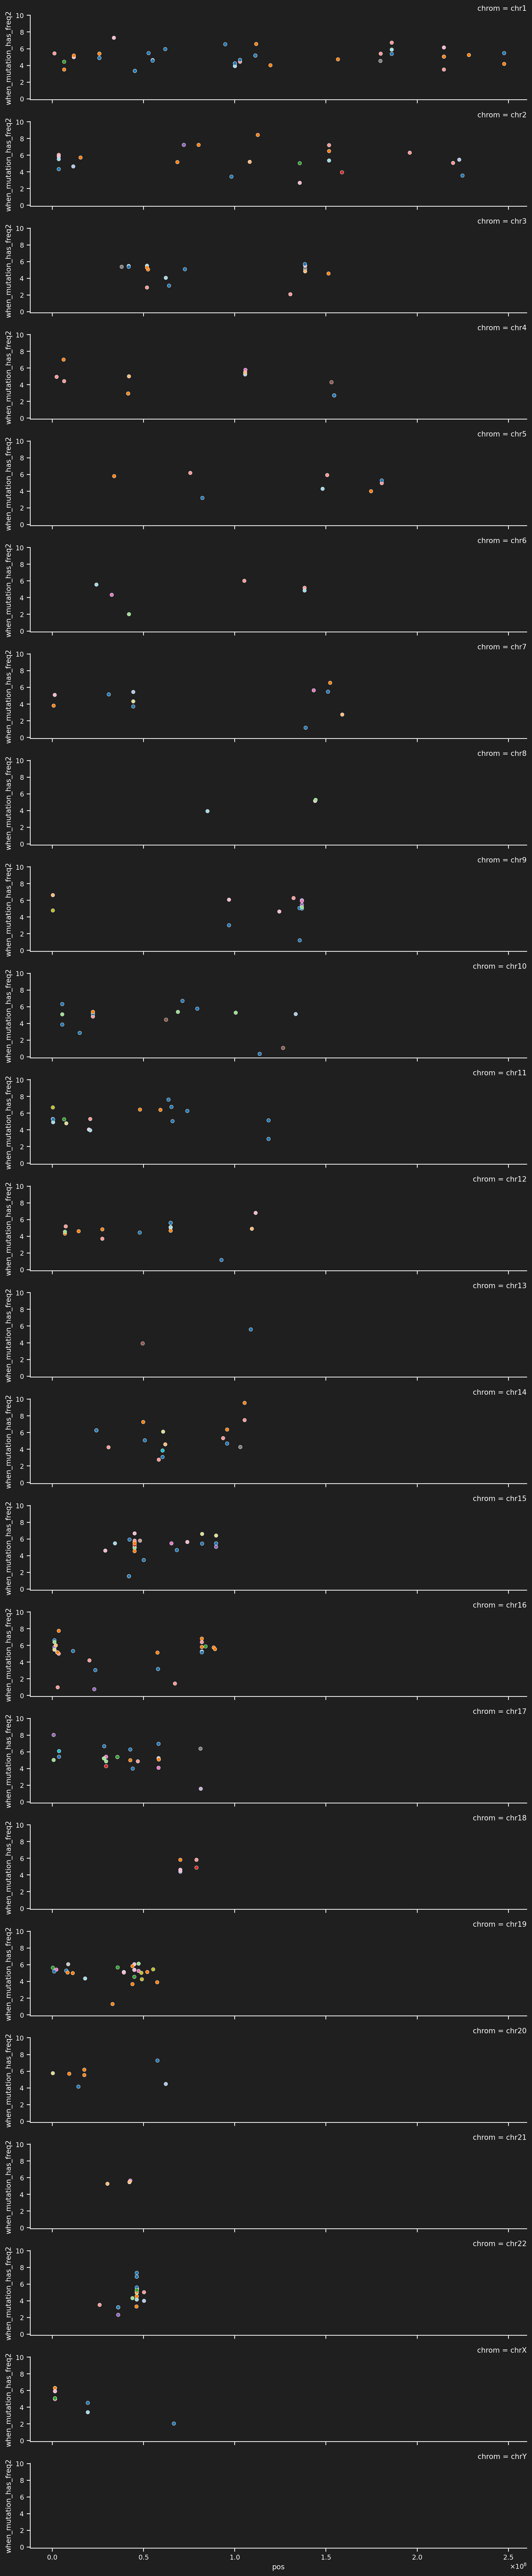

In [90]:
with theme(style='ticks', figsize=(15, 15)):
    g = sns.FacetGrid(plot_df, row='chrom', hue='pop', aspect=5, height=2, palette='tab20', sharex=True)
    g.map_dataframe(sns.scatterplot, x='pos', y='when_mutation_has_freq2') ;

In [ ]:
hum_var = all_variants_human[['species', 'gene_name', 'chromosome', 'variant_id',
        'allele_frequency',
       'cadd_phred', 'revel_score', ]].merge(
relate_df[['variant_id', 'when_mutation_has_freq2']].groupby('variant_id').max().reset_index(),
    left_on='variant_id', right_on='variant_id', how='left'
       )

In [ ]:
hum_var.loc[hum_var.gene_name.isin(['RBMX2', 'NKX2-4', 'IRS2', 'MYO16', 'SORCS3', 'DOCK2', 'IQCJ-SCHIP1', 'RASGRP3', 'HIVEP3', 'FGGY'])]

,species,gene_name,chromosome,variant_id,allele_frequency,cadd_phred,revel_score,when_mutation_has_freq2
973,human,MYO16,13,13-108844465-T-C,0.122894,0.197,NaN,5.59059
974,human,MYO16,13,13-109009011-C-G,0.393333,22.700,0.441,NaN
975,human,MYO16,13,13-109125155-A-G,0.138342,7.800,0.220,NaN
976,human,IRS2,13,13-109782884-C-T,0.332485,8.280,0.052,NaN
14842,human,HIVEP3,1,1-41510657-T-C,0.996388,0.272,0.042,NaN
14843,human,HIVEP3,1,1-41512895-T-G,0.999440,14.400,0.017,NaN
14844,human,HIVEP3,1,1-41513154-C-G,0.999438,14.800,0.077,NaN
14845,human,HIVEP3,1,1-41583074-T-C,0.998977,13.400,0.028,NaN
14846,human,HIVEP3,1,1-41584695-C-T,0.267114,0.110,0.030,NaN
14972,human,FGGY,1,1-59321678-T-G,0.404928,6.550,0.051,NaN


In [23]:
hum_var.loc[(hum_var.gene_name.str.startswith('TTLL')) & (hum_var.cadd_phred > 20)]

,species,gene_name,chromosome,variant_id,allele_frequency,cadd_phred,revel_score,when_mutation_has_freq2
1256,human,TTLL12,22,22-43172506-C-T,0.241681,24.2,0.171,NaN
1343,human,TTLL8,22,22-50032087-C-T,0.206287,21.8,0.204,NaN
5327,human,TTLL5,14,14-75690266-C-T,0.623317,22.8,0.056,NaN
13278,human,TTLL13,15,15-90253326-G-A,0.286447,21.4,0.069,NaN
13279,human,TTLL13,15,15-90257217-C-T,0.285143,20.6,0.126,NaN


In [22]:
plt.scatter(hum_var.allele_frequency, hum_var.cadd_phred, alpha=0.1)


In [21]:
hum_var.sort_values(['when_mutation_has_freq2'])

,species,gene_name,chromosome,variant_id,allele_frequency,cadd_phred,revel_score,when_mutation_has_freq2
5494,human,PACS2,14,14-105367342-A-G,0.117579,6.190,0.080,-9.56315
6230,human,NT5DC4,2,2-112725202-A-C,0.982189,13.900,NaN,-8.41311
9793,human,GEMIN4,17,17-744946-G-A,0.658141,25.400,0.186,-8.01193
16344,human,SLX4,16,16-3590273-G-A,0.199880,5.370,0.028,-7.73593
9337,human,RTN3,11,11-63719914-T-C,0.801820,4.230,0.031,-7.62798
...,...,...,...,...,...,...,...,...
18644,human,IQCG,3,3-197932289-C-G,0.248446,23.900,0.201,NaN
18645,human,IQCG,3,3-197938728-G-T,0.248504,0.029,0.103,NaN
18646,human,TNK2,3,3-195868079-G-A,0.213131,1.860,NaN,NaN
18647,human,FYTTD1,3,3-197768463-G-A,0.835541,22.500,0.085,NaN


In [47]:
hum_var.loc[(hum_var.when_mutation_has_freq2 > 6) & (hum_var.cadd_phred > 20)].sort_values(['when_mutation_has_freq2'])

,species,gene_name,chromosome,variant_id,allele_frequency,cadd_phred,revel_score,when_mutation_has_freq2
5239,human,SIX4,14,14-60713939-T-G,0.695740,23.3,0.263,6.08972
5051,human,ENSG00000254692,14,14-24210671-C-T,0.487304,29.1,0.524,6.26238
5106,human,CHMP4A,14,14-24210671-C-T,0.487304,29.1,0.524,6.26238
6553,human,DNAH7,2,2-195987187-G-A,0.657216,23.3,0.120,6.30303
5393,human,TUNAR,14,14-95922836-A-G,0.270169,22.1,NaN,6.35846
9175,human,OR5AN1,11,11-59365325-G-C,0.687040,23.1,NaN,6.40321
13210,human,EFL1,15,15-82163886-T-C,0.140857,24.8,0.180,6.59749
7706,human,DOCK8,9,9-286593-C-A,0.501356,23.2,0.201,6.62517
6994,human,WFS1,4,4-6301627-G-A,0.543770,22.5,0.486,7.00367
6367,human,NEB,2,2-151671058-C-T,0.801976,24.8,0.085,7.18516


::: {.callout-note}

Jupyter-scatter

:::

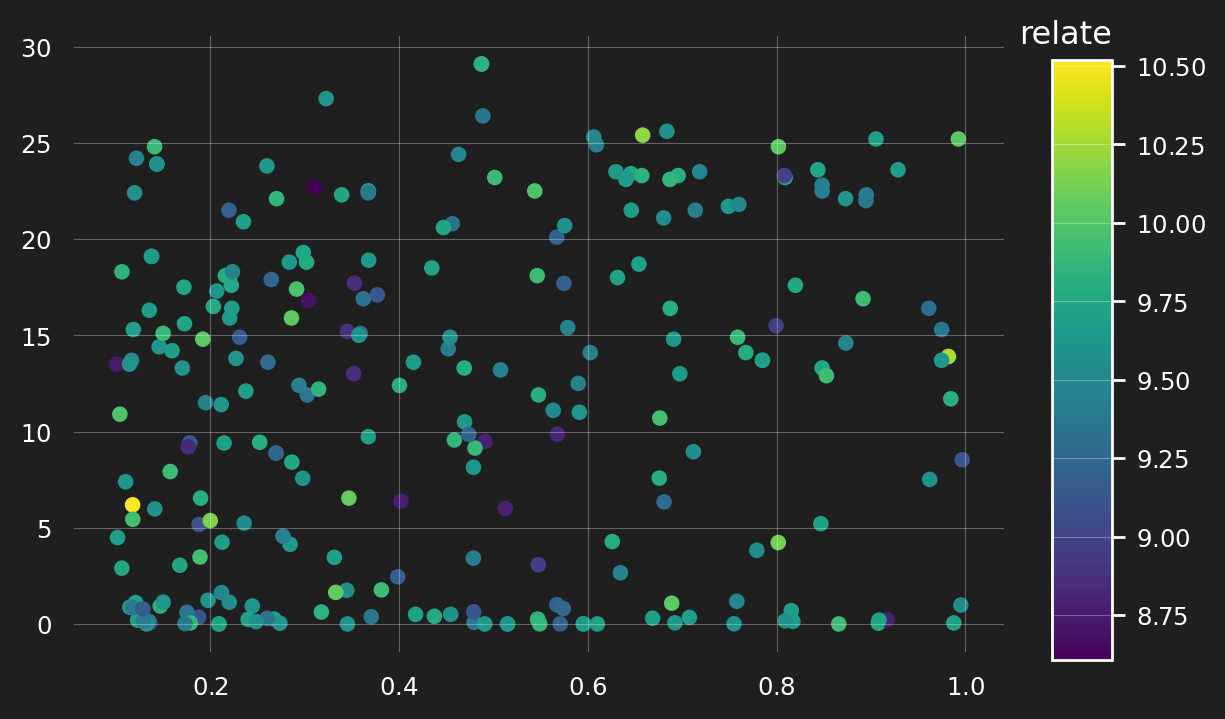

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(hum_var.allele_frequency, hum_var.cadd_phred, c=hum_var.when_mutation_has_freq2)

norm = plt.Normalize(hum_var.when_mutation_has_freq2.max(), hum_var.when_mutation_has_freq2.max())
cax = fig.add_axes([0.94, 0.1, 0.05, 0.75])  # [left, bottom, width 5% of figure width, height 75% of figure height]
cax.set_title('relate')
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cax, orientation='vertical')

plt.show()

In [ ]:

norm = plt.Normalize(hum_var.when_mutation_has_freq2.min(), hum_var.when_mutation_has_freq2.max())
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm.set_array([])

#plt.gca().get_legend().remove()
plt.gca().figure.colorbar(sm)

In [ ]:
plt.scatter(hum_var.when_mutation_has_freq2, hum_var.cadd_phred, c=) ;

SyntaxError: expected argument value expression (576726623.py, line 1)

In [275]:
all_variants_human[['variant_id',
        'allele_frequency',
       'cadd_phred', 'revel_score', ]].sort_values(['variant_id']).head()

,variant_id,allele_frequency,cadd_phred,revel_score
15114,1-100110377-G-A,0.407700,14.9,0.225
15120,1-100133310-G-A,0.848314,22.5,0.015
15121,1-100133311-C-T,0.848320,22.8,0.035
15119,1-100206504-T-C,0.911039,12.5,0.117
15116,1-100539534-G-A,0.522867,12.6,0.053


In [ ]:

relate_df.merge(all_variants_human[['species', 'gene_name', 'variant_id',
        'allele_frequency',
       'cadd_phred', 'revel_score', ]], left_on='variant_id', right_on='variant_id', how='left')

,chrom,pos,rs_id,variant_id,pop,when_DAF_is_half,when_mutation_has_freq2,species,gene_name,allele_frequency,cadd_phred,revel_score
0,chr1,100007048.0,1:100007048:A:G,1-100007048-A-G,IBS,-0.951873,-5.50639,NaN,NaN,NaN,NaN,NaN
1,chr1,100007871.0,1:100007871:T:A,1-100007871-T-A,IBS,-0.951873,-5.50639,NaN,NaN,NaN,NaN,NaN
2,chr1,100011106.0,1:100011106:G:A,1-100011106-G-A,IBS,-0.951873,-5.50639,NaN,NaN,NaN,NaN,NaN
3,chr1,100017453.0,1:100017453:C:A,1-100017453-C-A,MXL,-1.267670,-5.45390,NaN,NaN,NaN,NaN,NaN
4,chr1,100017453.0,1:100017453:C:A,1-100017453-C-A,IBS,-0.951873,-5.50639,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8674290,NaN,NaN,X:99999857:C:T,X-99999857-C-T,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8674291,NaN,NaN,X:99999857:C:T,X-99999857-C-T,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8674292,NaN,NaN,X:99999857:C:T,X-99999857-C-T,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8674293,NaN,NaN,X:99999857:C:T,X-99999857-C-T,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [252]:
all_variants_human_sel = all_variants_human.merge(relate_df[['pop', 'when_DAF_is_half', 'when_mutation_has_freq2']], left_index=True, right_index=True, how='left')

0.12156862745098039


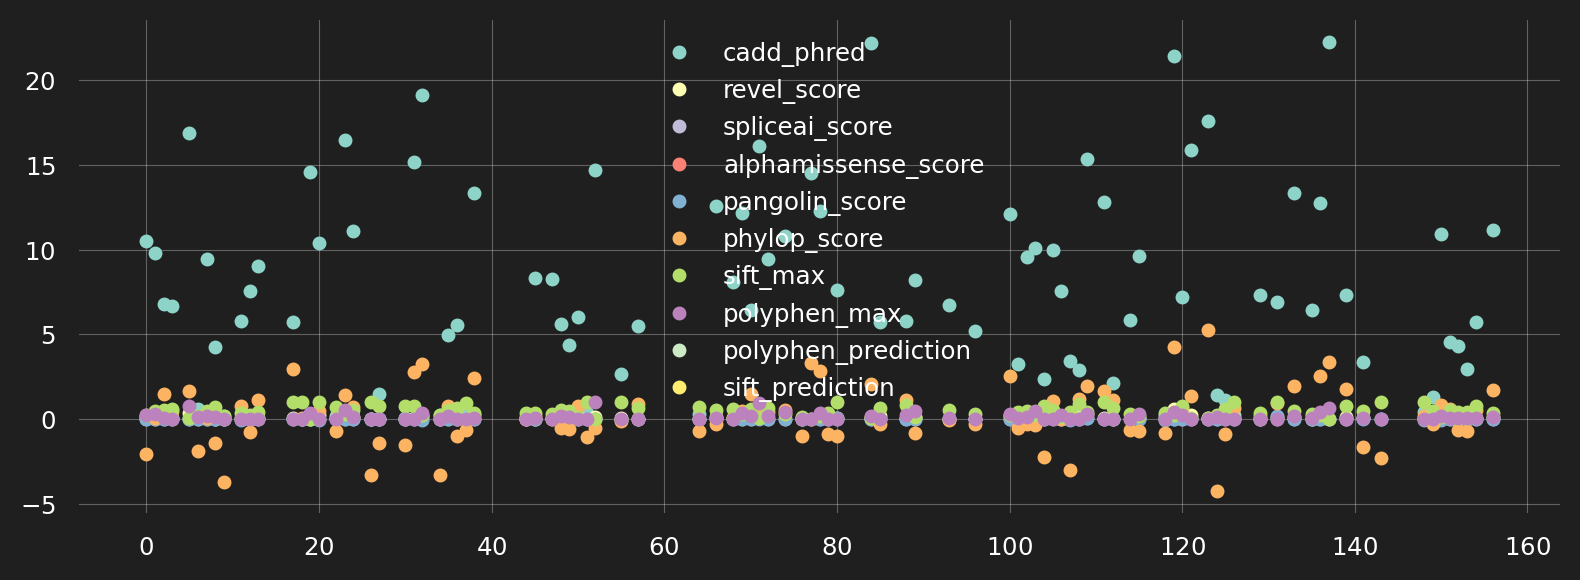

In [ ]:
# pathogenicity_score = pscore

df = all_variants_human_sel.loc[all_variants_human_sel.chromosome == 'X', ['species', 'gene_name', 'variant_id',
       'chromosome', 'genomic_position', 'ref_allele', 'alt_allele', 'allele_frequency',
       'cadd_phred', 'revel_score', 'spliceai_score', 'alphamissense_score',
        'pangolin_score', 'phylop_score', 'sift_max', 'polyphen_max',
        'polyphen_prediction', 'sift_prediction', 'lof', 
       ]]

pathogenicity_scores = ['cadd_phred', 'revel_score', 'spliceai_score', 'alphamissense_score',
        'pangolin_score', 'phylop_score', 'sift_max', 'polyphen_max',
        'polyphen_prediction', 'sift_prediction']

df['window'] = (df.genomic_position // 1_000_000)

with theme(figsize=(8,3)):
    for i, score in enumerate(pathogenicity_scores):
        _df = df.loc[:, ['chromosome', 'window', score]]
        _df['af_pathogenicity'] = df.allele_frequency * df[score]
        plot_df = _df.groupby(['chromosome', 'window']).mean().reset_index()
        plt.plot(plot_df.window, plot_df[score], marker='o', linestyle='None', markersize=4, label=score) 
    plt.legend()      
    plt.tight_layout()


## SNPs across chrX

0.12156862745098039


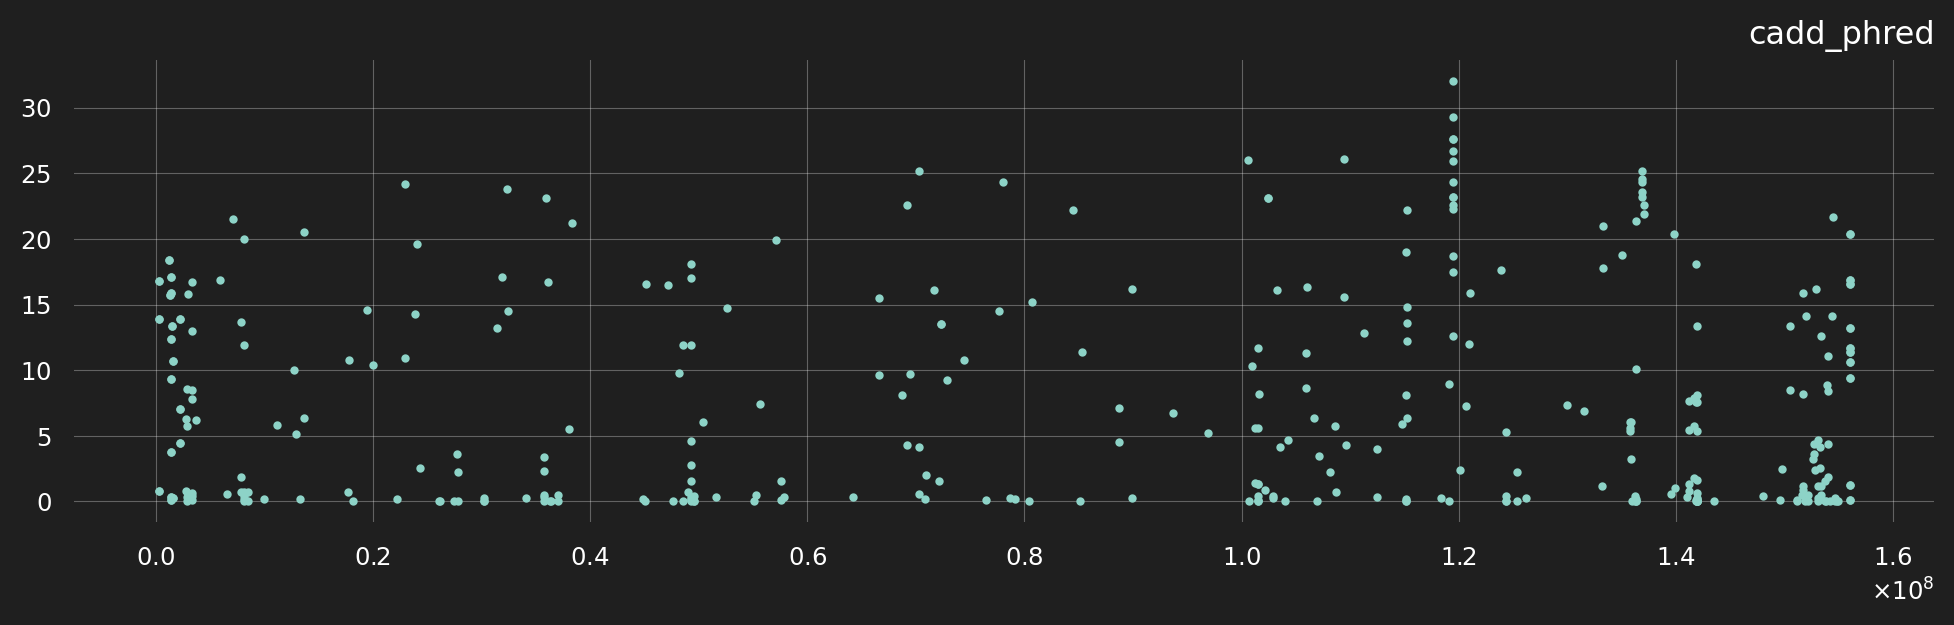

In [202]:
pscore = 'cadd_phred'
with theme(figsize=(12,3)):
    plt.plot(df.genomic_position, df[pscore], marker='o', linestyle='None', markersize=2, label=pscore) 
    plt.title(pscore)    

In [203]:
cadd_top_snps = df.loc[df[pscore] > 20, ['gene_name', 'variant_id', pscore]].sort_values(by=pscore, ascending=False)
cadd_top_snps

,gene_name,variant_id,cadd_phred
619,SLC25A5,X-119470481-G-C,32.0
609,SLC25A5,X-119469766-G-A,29.3
611,SLC25A5,X-119469784-A-T,27.6
610,SLC25A5,X-119469779-A-C,27.6
614,SLC25A5,X-119469910-G-T,26.7
582,GUCY2F,X-109465323-A-G,26.1
579,TSPAN6,X-100635207-C-T,26.0
615,SLC25A5,X-119469962-G-A,25.9
538,KIF4A,X-70341930-T-G,25.2
663,RBMX,X-136874347-C-G,25.2


In [204]:
cadd_top_genes = glist(cadd_top_snps.groupby('gene_name')[pscore].max().index.tolist())
cadd_top_genes

ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


0.12156862745098039


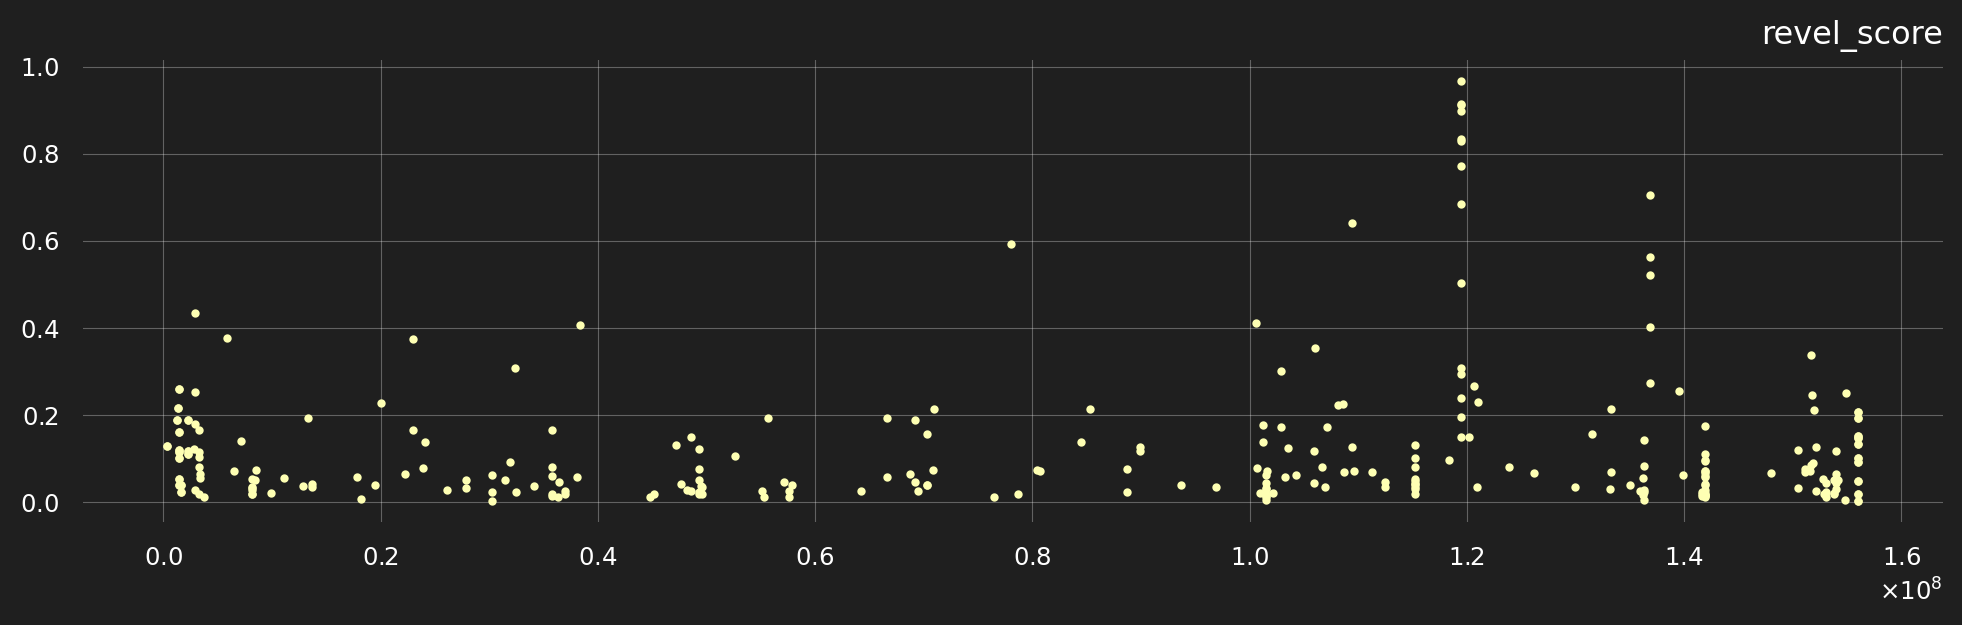

In [205]:
pscore = 'revel_score'
with theme(figsize=(12,3)):
    plt.plot(df.genomic_position, df[pscore], marker='o', linestyle='None', markersize=2, label=pscore, c='C1') 
    plt.title(pscore)

In [206]:
revel_top_snps = df.loc[df[pscore] > 0.5, ['gene_name', 'variant_id', pscore]].sort_values(by=pscore, ascending=False)
revel_top_snps

,gene_name,variant_id,revel_score
609,SLC25A5,X-119469766-G-A,0.966
614,SLC25A5,X-119469910-G-T,0.914
611,SLC25A5,X-119469784-A-T,0.912
615,SLC25A5,X-119469962-G-A,0.899
619,SLC25A5,X-119470481-G-C,0.834
610,SLC25A5,X-119469779-A-C,0.829
613,SLC25A5,X-119469901-G-A,0.772
661,RBMX,X-136874303-G-C,0.706
616,SLC25A5,X-119470436-C-G,0.685
582,GUCY2F,X-109465323-A-G,0.641


In [207]:
revel_top_genes = glist(revel_top_snps.groupby('gene_name')[pscore].max().index.tolist())
revel_top_genes

ATP7A,GUCY2F,RBMX,SLC25A5


In [208]:
cadd_top_genes << revel_top_genes

ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [209]:
from geneinfo.genelist import GeneListCollection
gene_lists = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')


In [210]:
cadd_top_genes <<  gene_lists.get('gametologs') << gene_lists.get('ari_nonPUR') 

ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [211]:
cadd_top_genes << gene_lists.get('mult_copy') << gene_lists.get('ari_nonPUR') 

ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [212]:

cadd_top_genes << gene_lists.get('nDEG') << gene_lists.get('ari_nonPUR') 

ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [213]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

iridis = truncate_colormap('viridis', minval=0.1)


In [214]:
# _df = plot_df.loc[plot_df.allele_frequency * plot_df['cadd_phred'] > 5, ['gene_name', 'allele_frequency', 'cadd_phred']]
# [tuple(t) for t in _df.itertuples()]

0.12156862745098039


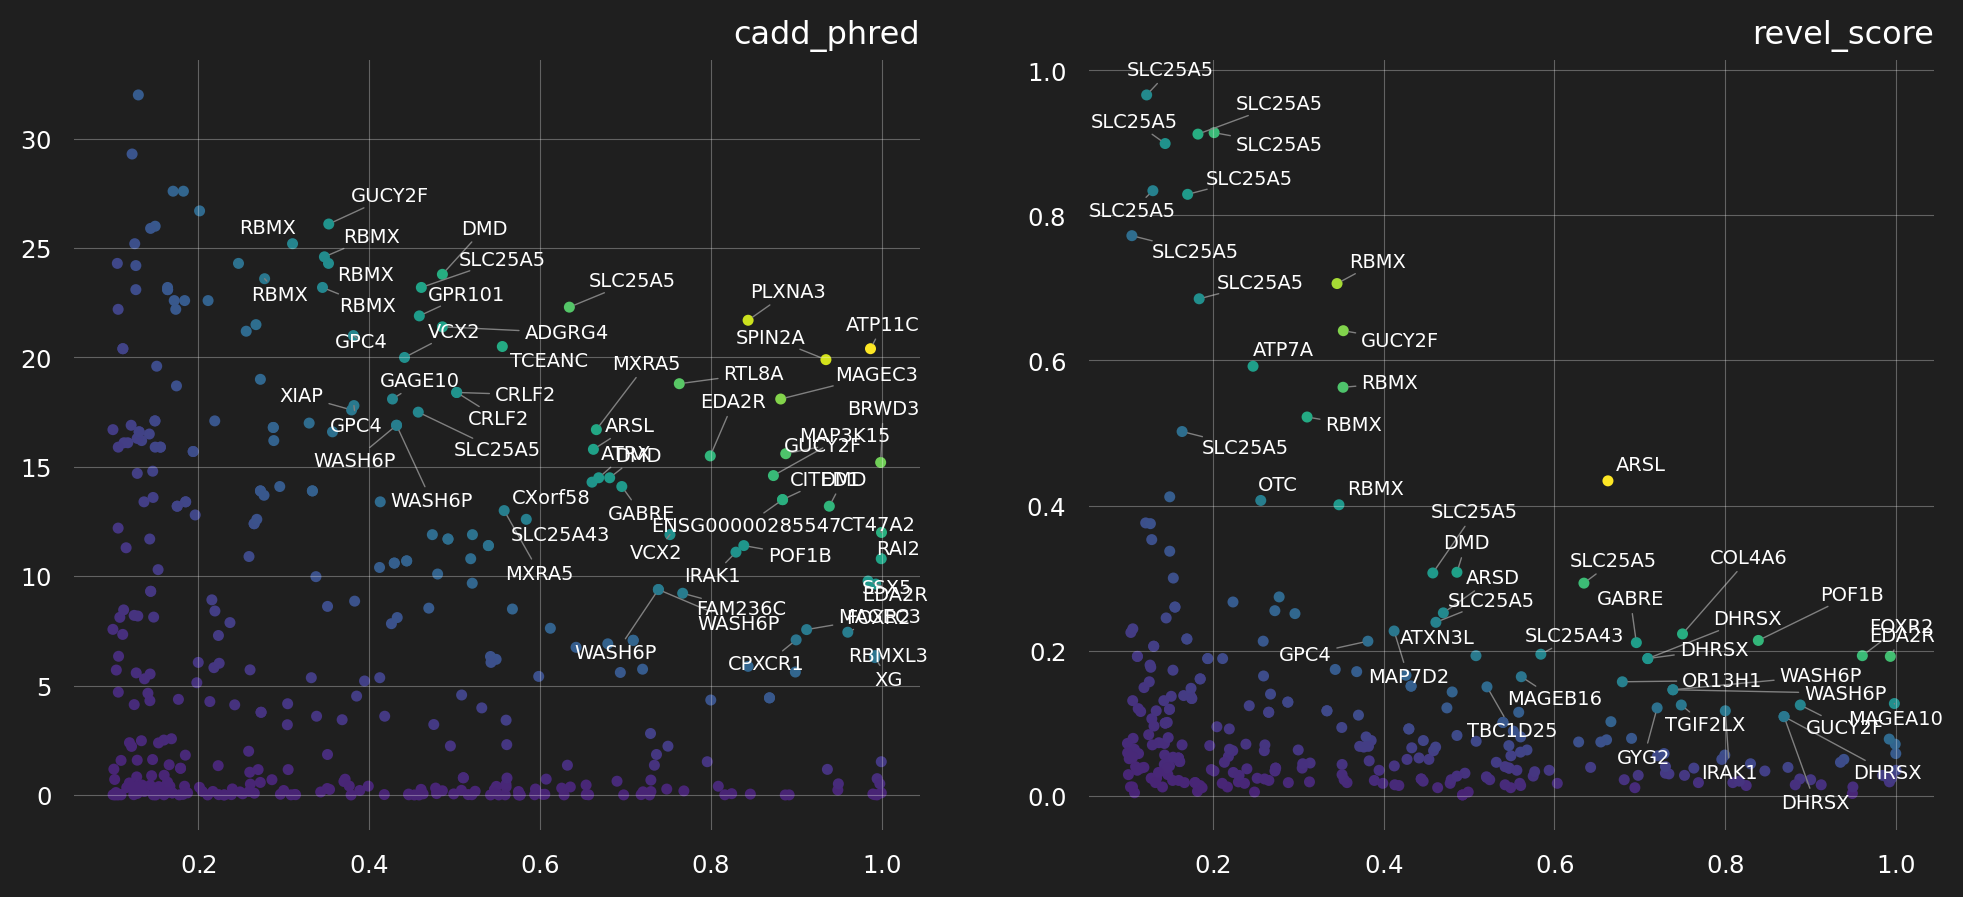

In [218]:
from adjustText import adjust_text
from contextlib import redirect_stdout


with theme(figsize=(12,5)):

    for i, pscore in enumerate(['cadd_phred', 'revel_score']):
        plt.subplot(1, 2, i+1).scatter(df.allele_frequency, df[pscore], marker='.', 
                                c=df.allele_frequency * df[pscore], cmap=iridis, s=40)
        plt.title(pscore)

        af_pat = df.allele_frequency * df[pscore] 
        threshold = af_pat.quantile(q=0.85)
        _df = df.loc[af_pat > threshold, ['allele_frequency', pscore, 'gene_name']]
                        
        tups = [tuple(t) for t in _df.itertuples(index=False)]
        texts = [plt.text(*t, fontsize=7) for t in tups]
        x, y, t = zip(*tups)
        with redirect_stdout(None):
            texts, patches = adjust_text(texts, x, y, expand=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.5)) 


0.12156862745098039


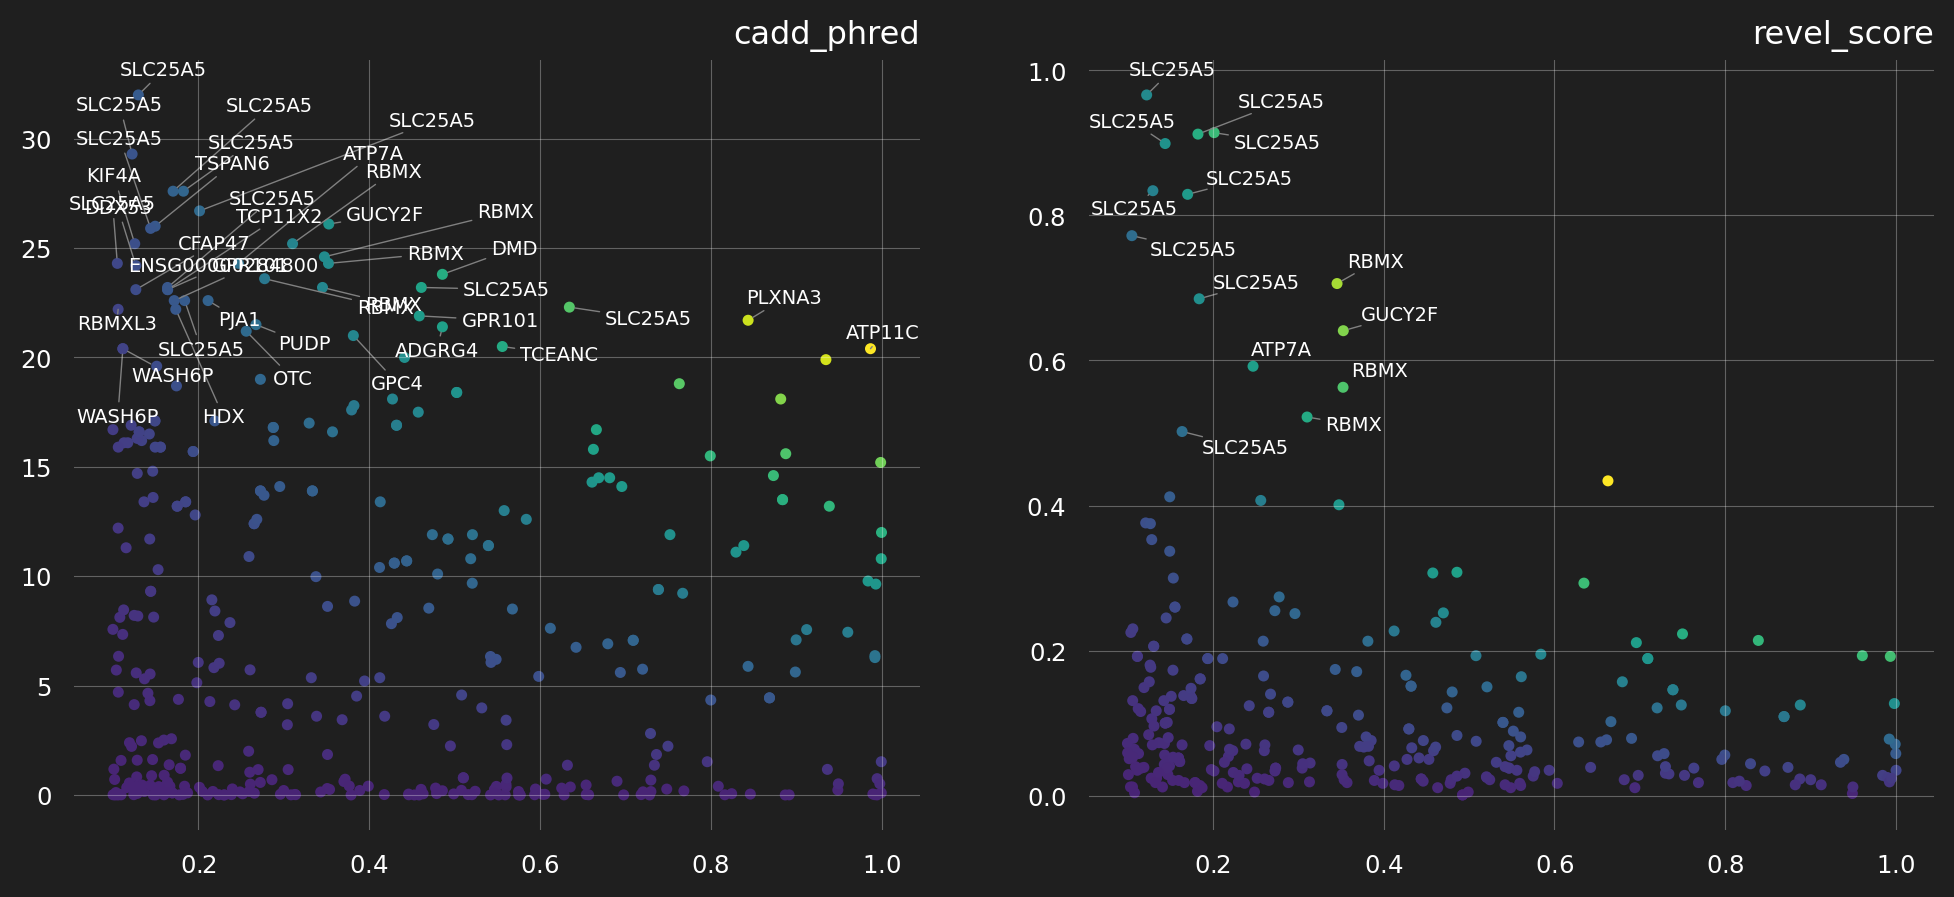

In [ ]:
with theme(figsize=(12,5)):

    for i, pscore in enumerate(['cadd_phred', 'revel_score']):
        plt.subplot(1, 2, i+1).scatter(df.allele_frequency, df[pscore], marker='.', 
                                c=df.allele_frequency * df[pscore], cmap=iridis, s=40)
        plt.title(pscore)
        af_pat = df.allele_frequency * df[pscore] 
        threshold = 20 if pscore == 'cadd_phred' else 0.5
        _df = df.loc[df[pscore] > threshold, ['allele_frequency', pscore, 'gene_name']]
        tups = [tuple(t) for t in _df.itertuples(index=False)]
        texts = [plt.text(*t, fontsize=7) for t in tups]
        x, y, t = zip(*tups)
        with redirect_stdout(None):
            texts, patches = adjust_text(texts, x, y, expand=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.5)) 

0.12156862745098039


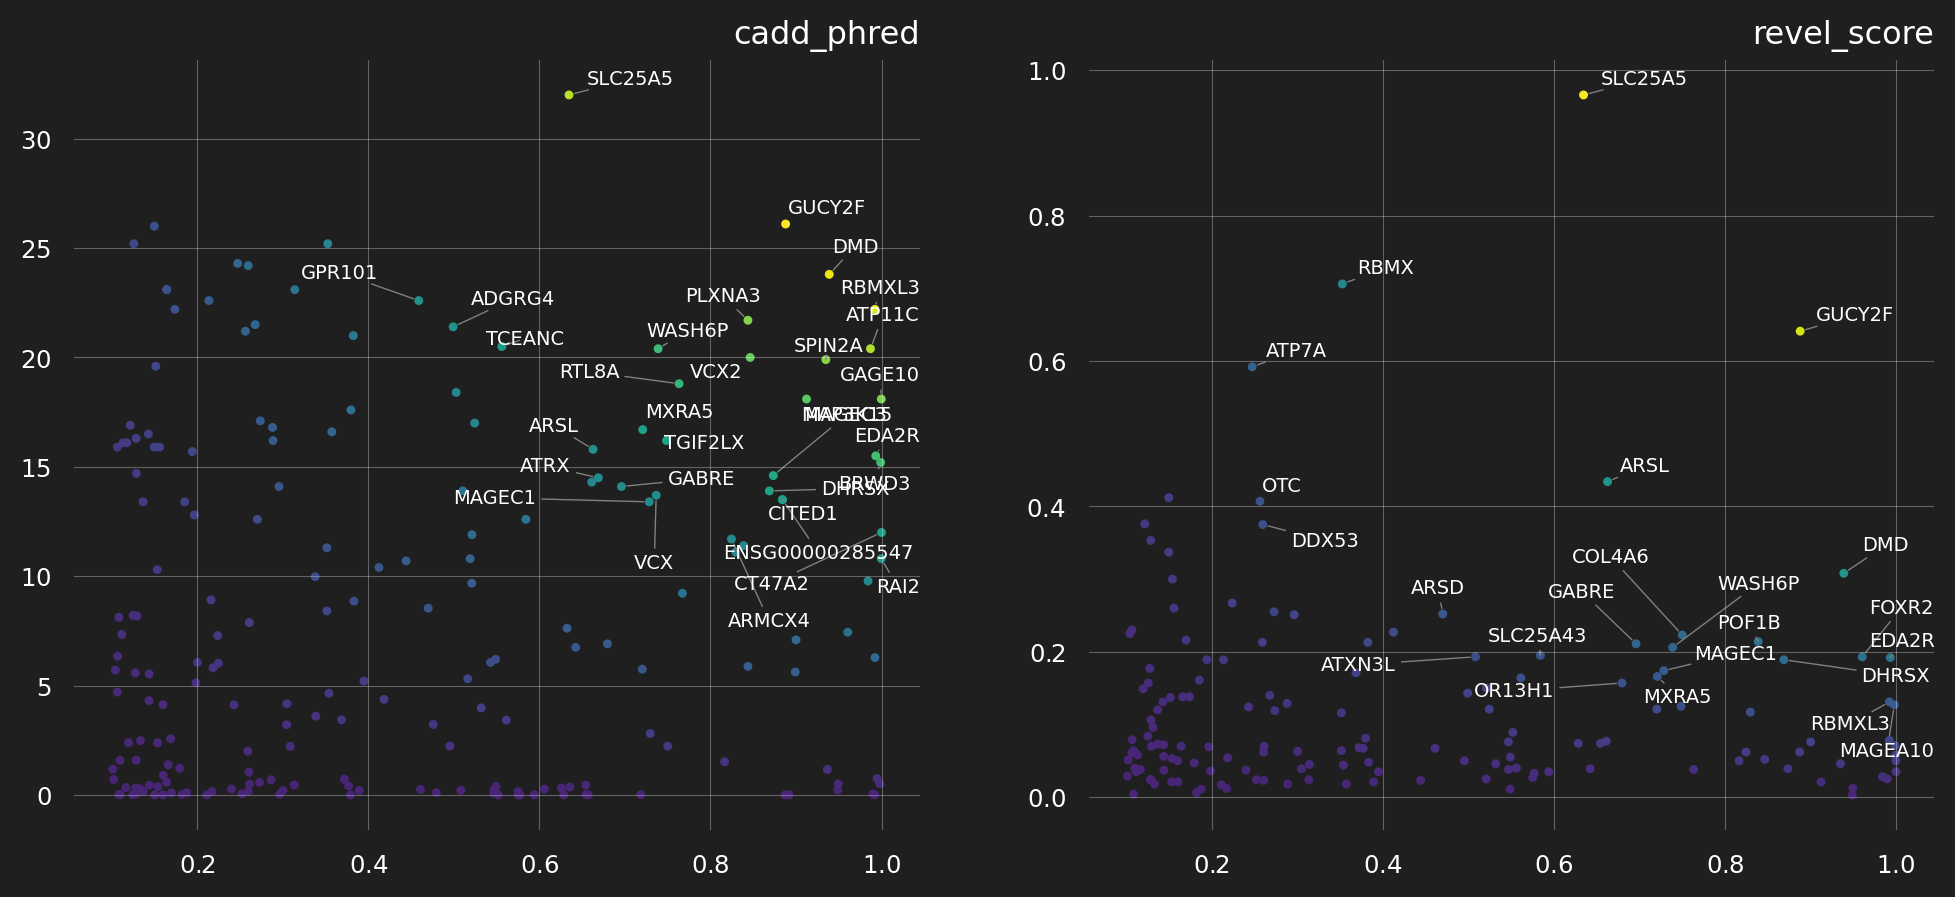

In [ ]:
from adjustText import adjust_text

with theme(figsize=(12,5)):

    for i, pscore in enumerate(['cadd_phred', 'revel_score']):

        plot_df = df.groupby(['gene_name']).max().reset_index()

        plt.subplot(1, 2, i+1).scatter(plot_df.allele_frequency, plot_df[pscore], marker='.', 
                                c=plot_df.allele_frequency * plot_df[pscore], cmap=iridis)
        plt.title(pscore)
        af_pat = plot_df.allele_frequency * plot_df[pscore] 
        threshbold = af_pat.quantile(q=0.85)
        _df = plot_df.loc[af_pat > threshbold, ['allele_frequency', pscore, 'gene_name']]

        tups = [tuple(t) for t in _df.itertuples(index=False)]
        texts = [plt.text(*t, fontsize=7) for t in tups]
        x, y, t = zip(*tups)
        texts, patches = adjust_text(texts, x, y, expand=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.5)) 

0.12156862745098039


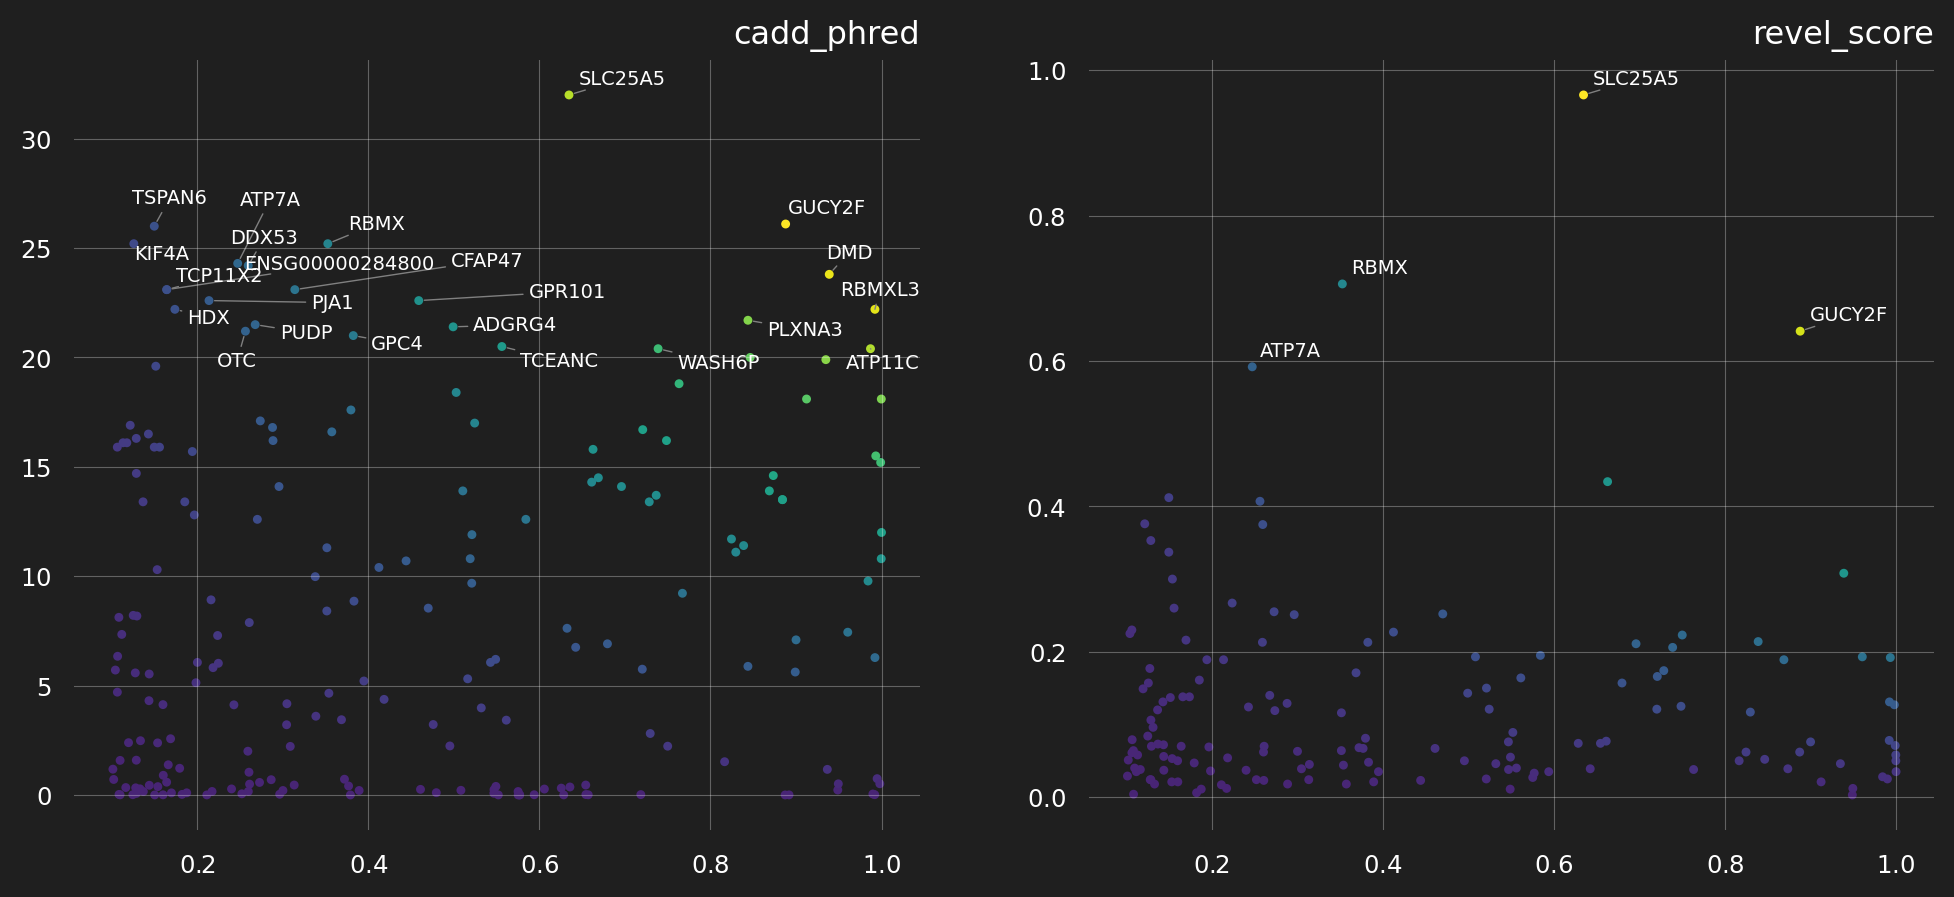

In [226]:
with theme(figsize=(12,5)):

    for i, pscore in enumerate(['cadd_phred', 'revel_score']):

        plot_df = df.groupby(['gene_name']).max().reset_index()

        plt.subplot(1, 2, i+1).scatter(plot_df.allele_frequency, plot_df[pscore], marker='.', 
                                c=plot_df.allele_frequency * plot_df[pscore], cmap=iridis)
        plt.title(pscore)
        af_pat = plot_df.allele_frequency * plot_df[pscore] 
        threshbold = 20 if pscore == 'cadd_phred' else 0.5
        _df = plot_df.loc[plot_df[pscore] > threshbold, ['allele_frequency', pscore, 'gene_name']]

        tups = [tuple(t) for t in _df.itertuples(index=False)]
        texts = [plt.text(*t, fontsize=7) for t in tups]
        x, y, t = zip(*tups)
        texts, patches = adjust_text(texts, x, y, expand=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.5)) 

0.12156862745098039


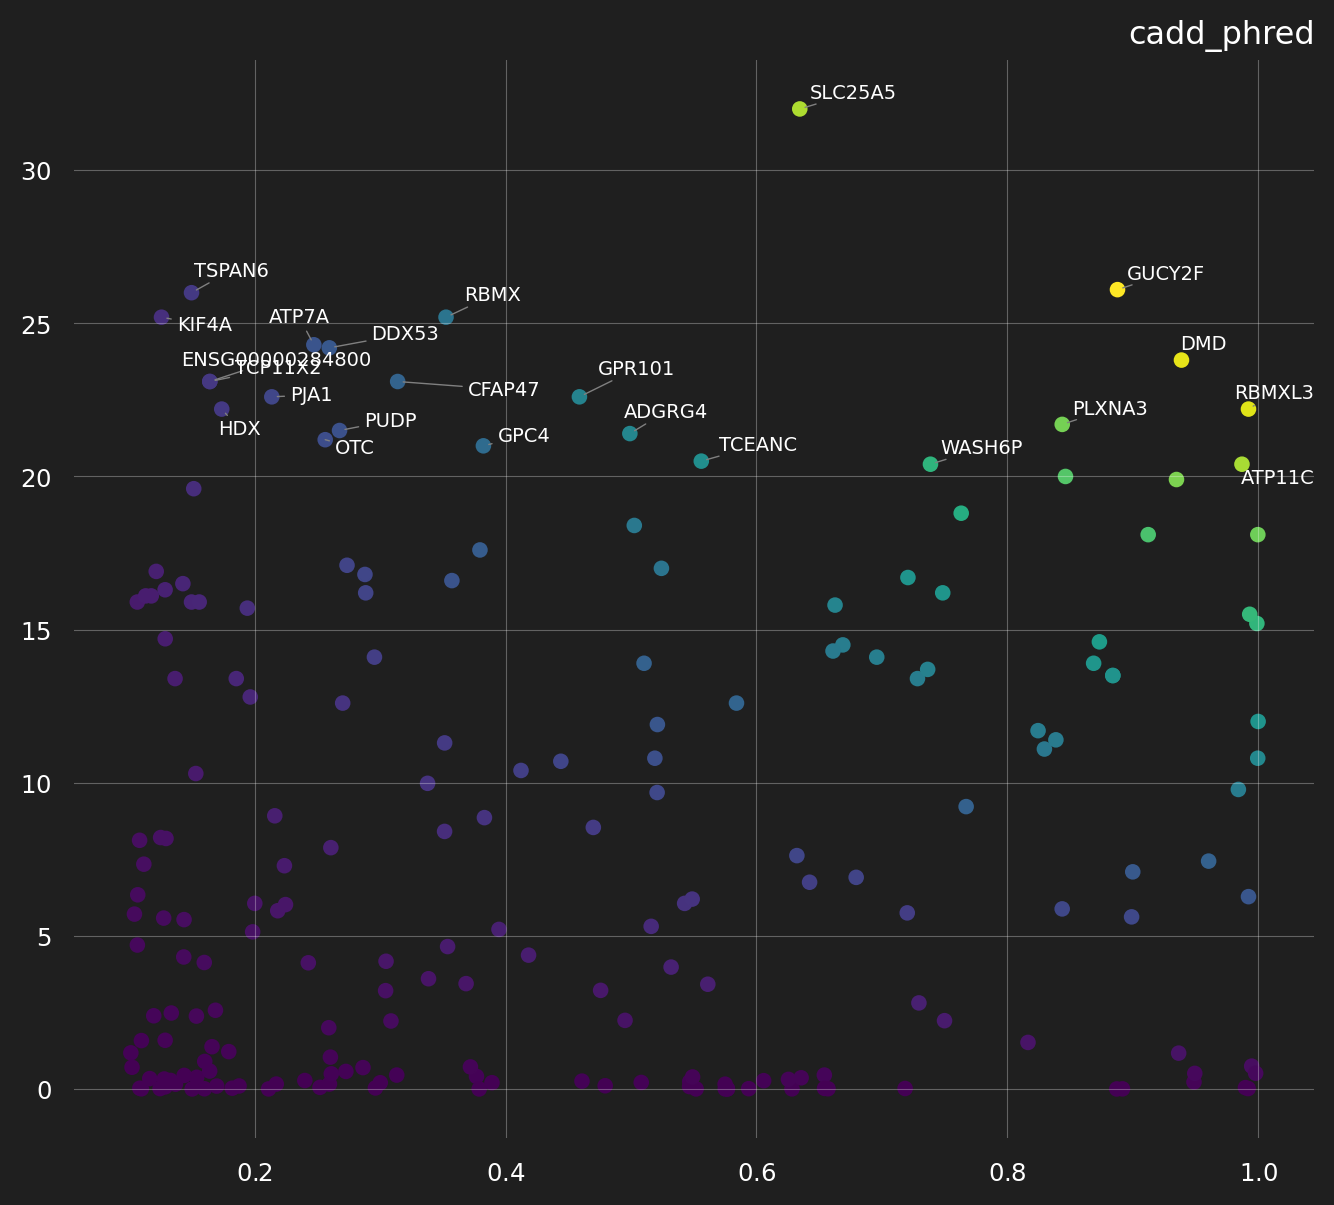

In [235]:
with theme(figsize=(8,7)):

    pscore = 'cadd_phred'

    plot_df = df.groupby(['gene_name']).max().reset_index()

    plt.scatter(plot_df.allele_frequency, plot_df[pscore], #s=10,
                            c=plot_df.allele_frequency * plot_df[pscore], cmap=iridis)
    plt.title(pscore)
    af_pat = plot_df.allele_frequency * plot_df[pscore] 
    threshbold = 20 if pscore == 'cadd_phred' else 0.5
    _df = plot_df.loc[plot_df[pscore] > threshbold, ['allele_frequency', pscore, 'gene_name']]

    tups = [tuple(t) for t in _df.itertuples(index=False)]
    texts = [plt.text(*t, fontsize=7) for t in tups]
    x, y, candidates = zip(*tups)
    texts, patches = adjust_text(texts, x, y, expand=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.5)) 


In [241]:
glist(candidates) << gene_lists.get('mult_copy') << gene_lists.get('sfari_all_conf')


ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [244]:
glist(candidates) << gene_lists.get('mult_copy') << gene_lists.get('hum_nean_admix') << gene_lists.get('circRNA')


ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [245]:
glist(candidates) << gene_lists.get('mult_copy') << gene_lists.get('circRNA')


ADGRG4,DDX53,GPR101,OTC,RBMX,TCP11X2
ATP11C,DMD,GUCY2F,PJA1,RBMXL3,TSPAN6
ATP7A,ENSG00000284800,HDX,PLXNA3,SLC25A5,WASH6P
CFAP47,GPC4,KIF4A,PUDP,TCEANC,


In [124]:
gene_info('ARSL')

**Symbol:** **_ARSL_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** ARSE, ASE, CDPX, CDPX1, CDPXR  
*arylsulfatase L*  
**Summary:** Arylsulfatase E is a member of the sulfatase family. It is glycosylated postranslationally and localized to the golgi apparatus. Sulfatases are essential for the correct composition of bone and cartilage matrix. X-linked chondrodysplasia punctata, a disease characterized by abnormalities in cartilage and bone development, has been linked to mutations in this gene. Alternative splicing results in multiple transcript variants. A pseudogene related to this gene is located on the Y chromosome. [provided by RefSeq, Sep 2013].  
**Human genomic position:** X:2934045-2968475 (hg38), X:2852699-2886286 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=ARSL)  


 ----

# common_missense_human_gnomad

In [ ]:
# common_miss = pd.read_csv('../results/common_missense_human_gnomad.csv')
# common_miss

,species,gene_id,gene_name,transcript_id,variant_id,chromosome,genomic_position,ref_allele,alt_allele,aa_position,ref_aa,alt_aa,allele_frequency,hgvsp,hgvsc,consequence,source
0,human,ENSG00000169084,DHRSX,ENST00000334651,X-2221145-C-T,X,2221145,C,T,297,Glu,Lys,0.333643,p.Glu297Lys,c.889G>A,missense_variant,gnomAD_v4
1,human,ENSG00000169084,DHRSX,ENST00000334651,X-2221159-T-C,X,2221159,T,C,292,His,Arg,0.868850,p.His292Arg,c.875A>G,missense_variant,gnomAD_v4
2,human,ENSG00000169084,DHRSX,ENST00000334651,X-2243088-C-G,X,2243088,C,G,247,Val,Leu,0.709305,p.Val247Leu,c.739G>C,missense_variant,gnomAD_v4
3,human,ENSG00000205755,CRLF2,ENST00000400841,X-1193297-T-C,X,1193297,T,C,258,Lys,Arg,0.502598,p.Lys258Arg,c.773A>G,missense_variant,gnomAD_v4
4,human,ENSG00000196433,ASMT,ENST00000381241,X-1632709-T-C,X,1632709,T,C,190,Trp,Arg,0.444030,p.Trp190Arg,c.568T>C,missense_variant,gnomAD_v4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17204,human,ENSG00000114473,IQCG,ENST00000265239,3-197932289-C-G,3,197932289,C,G,177,Asp,His,0.248446,p.Asp177His,c.529G>C,missense_variant,gnomAD_v4
17205,human,ENSG00000114473,IQCG,ENST00000265239,3-197938728-G-T,3,197938728,G,T,112,Ala,Asp,0.248504,p.Ala112Asp,c.335C>A,missense_variant,gnomAD_v4
17206,human,ENSG00000061938,TNK2,ENST00000672887,3-195868079-G-A,3,195868079,G,A,740,Pro,Leu,0.213131,p.Pro740Leu,c.2219C>T,missense_variant,gnomAD_v4
17207,human,ENSG00000122068,FYTTD1,ENST00000241502,3-197768463-G-A,3,197768463,G,A,87,Arg,His,0.835541,p.Arg87His,c.260G>A,missense_variant,gnomAD_v4


# how do LoFs overlap with human-neanderthal admixture?

In [302]:
all_lof = pd.read_parquet("../results/gnomad_lof/gnomad_lof_all_genes_20251206_003756.parquet")
all_lof


,gene_name,gene_id,transcript_id,variant_id,chrom,position,ref,alt,mutation_type,consequence,...,af_total,af_afr,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,af_sas,cds_relative_position
0,A1BG,ENSG00000121410,ENST00000263100,19-58858397-T-C,19,58858397,T,C,Splice acceptor,splice_acceptor_variant,...,0.000004,0.000000,0.000000,0.000000,0.000000,0.0,0.000009,0.000000,0.000000,Unknown
1,A1BG,ENSG00000121410,ENST00000263100,19-58858718-C-T,19,58858718,C,T,Splice donor,splice_donor_variant,...,0.000004,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000033,Unknown
2,A1BG,ENSG00000121410,ENST00000263100,19-58858752-C-A,19,58858752,C,A,In-frame stop codon,stop_gained,...,0.000004,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000033,Unknown
3,A1BG,ENSG00000121410,ENST00000263100,19-58858774-C-T,19,58858774,C,T,In-frame stop codon,stop_gained,...,0.000004,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000168,0.000000,Unknown
4,A1BG,ENSG00000121410,ENST00000263100,19-58858780-G-GTA,19,58858780,G,GTA,Frameshift,frameshift_variant,...,0.000008,0.000000,0.000000,0.000000,0.000113,0.0,0.000000,0.000000,0.000000,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715938,hsa-mir-1199,ENSG00000141854,ENST00000269720,19-14185236-G-GC,19,14185236,G,GC,Frameshift,frameshift_variant,...,0.000081,0.000000,0.000000,0.000121,0.000096,0.0,0.000094,0.000240,0.000134,Unknown
715939,hsa-mir-1199,ENSG00000141854,ENST00000269720,19-14185276-G-A,19,14185276,G,A,Splice donor,splice_donor_variant,...,0.000032,0.000115,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,Unknown
715940,hsa-mir-1199,ENSG00000141854,ENST00000269720,19-14185514-CCA-C,19,14185514,CCA,C,Splice acceptor,splice_acceptor_variant,...,0.000007,0.000000,0.000041,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,Unknown
715941,hsa-mir-1199,ENSG00000141854,ENST00000269720,19-14185516-A-AGGG,19,14185516,A,AGGG,Splice acceptor,splice_acceptor_variant,...,0.000007,0.000000,0.000041,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,Unknown


In [4]:
_df = all_lof.loc[(all_lof.af_total > 0.2) & (all_lof.af_total < 1)].sort_values('af_total', ascending=False)
_df.gene_name.unique()

NameError: name 'all_lof' is not defined

In [ ]:

_df[['chrom', 'position', 'variant_id', 'gene_name', 'af_total', 'af_afr', 'af_amr', 'af_asj', 
     'af_eas', 'af_fin', 'af_nfe', 'af_oth', 'af_sas']].sort_values(['chrom', 'position'])

In [337]:
_df[['chrom', 'position', 'variant_id', 'gene_name', 'af_total', 'af_afr', 'af_amr', 'af_asj', 
     'af_eas', 'af_fin', 'af_nfe', 'af_oth', 'af_sas']].sort_values(['chrom', 'position']).merge(
relate_df[['variant_id', 'when_mutation_has_freq2']].groupby('variant_id').min().reset_index(),
    left_on='variant_id', right_on='variant_id', how='left'
       ).sort_values('when_mutation_has_freq2')

,chrom,position,variant_id,gene_name,af_total,af_afr,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,af_sas,when_mutation_has_freq2
0,1,1558792,1-1558792-T-C,MIB2,0.867143,0.742605,0.810203,0.977045,0.570790,0.898262,0.937844,0.908905,0.856941,NaN
1,1,5935162,1-5935162-A-T,NPHP4,0.826383,0.893830,0.793563,0.754985,0.810119,0.920028,0.824384,0.814536,0.828184,NaN
2,1,12776344,1-12776344-A-T,AADACL3,0.783314,0.468350,0.842119,0.772754,0.638948,0.812755,0.833056,0.801354,0.756421,NaN
3,1,12854090,1-12854090-T-A,PRAMEF1,0.247492,0.072800,0.223961,0.306976,0.150685,0.339891,0.291538,0.208381,0.255548,NaN
4,1,15820307,1-15820307-A-AC,CASP9,0.212247,0.413732,0.136643,0.260870,0.064996,0.272101,0.225019,0.226776,0.211093,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,X,104464276,X-104464276-CA-C,TEX13A,0.999076,0.998861,0.998738,0.998047,0.999004,0.999229,0.999460,0.999024,0.998425,NaN
682,X,104464281,X-104464281-TC-T,TEX13A,0.998586,0.998092,0.997754,0.998348,0.997417,1.000000,0.999138,0.999342,0.997560,NaN
683,X,117904229,X-117904229-T-C,IL13RA1,0.262098,0.075758,0.434931,0.238046,0.467280,0.189189,0.160177,0.225668,0.282985,NaN
684,X,142967468,X-142967468-T-G,UBE2NL,0.630397,0.648075,0.544060,0.578968,0.658049,0.688231,0.665046,0.631102,0.545249,NaN


In [ ]:

lof_segr = glist(sorted(_df.gene_name.unique()))

lof_segr

In [ ]:
common_lof = common_miss.merge(all_lof, 
                               left_on=['gene_name', 'variant_id'], 
                               right_on=['gene_name', 'variant_id'], how='inner',
                                suffixes=('_com', '_lof')
                                )
common_lof

,species,gene_id_com,gene_name,transcript_id_com,variant_id,chromosome,genomic_position,ref_allele,alt_allele,aa_position,...,af_total,af_afr,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,af_sas,cds_relative_position


In [ ]:
common_lof = common_miss.merge(all_lof, 
                               left_on=['gene_name', 'genomic_position'], 
                               right_on=['gene_name', 'position'], how='inner',
                                suffixes=('_com', '_lof')
                                )
common_lof#[['gene_name', 'variant_id_com', 'variant_id_lof']]

,species,gene_id_com,gene_name,transcript_id_com,variant_id_com,chromosome,genomic_position,ref_allele,alt_allele,aa_position,...,af_total,af_afr,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,af_sas,cds_relative_position
0,human,ENSG00000145975,FAM217A,ENST00000274673,6-4068932-C-T,6,4068932,C,T,431,...,0.000243,0.003148,0.000202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Unknown
1,human,ENSG00000167664,TMIGD2,ENST00000301272,19-4294626-C-A,19,4294626,C,A,168,...,0.000057,0.000000,0.000413,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Unknown
2,human,ENSG00000116017,ARID3A,ENST00000263620,19-971949-G-A,19,971949,G,A,556,...,0.000028,0.000000,0.000106,0.000000,0.000000,0.000000,0.000021,0.000000,0.000036,Unknown
3,human,ENSG00000099866,MADCAM1,ENST00000215637,19-501719-T-C,19,501719,T,C,240,...,0.000143,0.000000,0.000000,0.000000,0.000000,0.001695,0.000000,0.000000,0.000000,Unknown
4,human,ENSG00000099866,MADCAM1,ENST00000215637,19-501719-T-C,19,501719,T,C,240,...,0.012564,0.003256,0.012821,0.022727,0.010714,0.038983,0.018282,0.024510,0.000000,Unknown
5,human,ENSG00000099866,MADCAM1,ENST00000215637,19-501719-T-C,19,501719,T,C,240,...,0.000286,0.000000,0.000000,0.000000,0.007143,0.000000,0.000000,0.000000,0.000000,Unknown
6,human,ENSG00000105289,TJP3,ENST00000541714,19-3750617-T-C,19,3750617,T,C,898,...,0.000070,0.000000,0.000089,0.000000,0.000000,0.000000,0.000082,0.000167,0.000136,Unknown
7,human,ENSG00000106714,CNTNAP3,ENST00000297668,9-39078846-A-G,9,39078846,A,G,1173,...,0.000032,0.000000,0.000000,0.000000,0.000644,0.000000,0.000000,0.000000,0.000000,Unknown
8,human,ENSG00000106714,CNTNAP3,ENST00000297668,9-39088492-T-A,9,39088492,T,A,1051,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Unknown
9,human,ENSG00000184956,MUC6,ENST00000421673,11-1016959-T-C,11,1016959,T,C,1948,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Unknown


In [41]:
gi.gene_info(common_lof.gene_name.unique().tolist())

**Symbol:** **_FAM217A_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** C6orf146  
*family with sequence similarity 217 member A*  
**Human genomic position:** 6:4049434-4087344 (hg38), 6:4049668-4087578 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=FAM217A)  


 ----

**Symbol:** **_TMIGD2_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** CD28H, IGPR-1, IGPR1  
*transmembrane and immunoglobulin domain containing 2*  
**Summary:** Enables coreceptor activity. Involved in positive regulation of T cell activation; positive regulation of angiogenesis; and positive regulation of cytokine production. Predicted to be located in plasma membrane. Predicted to be integral component of membrane. Predicted to be active in extracellular space. [provided by Alliance of Genome Resources, Apr 2022]  
**Human genomic position:** 19:4292227-4302431 (hg38), 19:4292229-4302428 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=TMIGD2)  


 ----

**Symbol:** **_ARID3A_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** BRIGHT, DRIL1, DRIL3, E2FBP1  
*AT-rich interaction domain 3A*  
**Summary:** This gene encodes a member of the ARID (AT-rich interaction domain) family of DNA binding proteins. It was found by homology to the Drosophila dead ringer gene, which is important for normal embryogenesis. Other ARID family members have roles in embryonic patterning, cell lineage gene regulation, cell cycle control, transcriptional regulation, and possibly in chromatin structure modification. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 19:924528-975939 (hg38), 19:925781-975939 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=ARID3A)  


 ----

**Symbol:** **_MADCAM1_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** MACAM1  
*mucosal vascular addressin cell adhesion molecule 1*  
**Summary:** The protein encoded by this gene is an endothelial cell adhesion molecule that interacts preferentially with the leukocyte beta7 integrin LPAM-1 (alpha4beta7), L-selectin, and VLA-4 (alpha4beta1) on myeloid cells to direct leukocytes into mucosal and inflamed tissues. It is a member of the immunoglobulin family and is similar to ICAM1 and VCAM1. At least seven alternatively spliced transcripts encoding different protein isoforms have been found for this gene, but the full-length nature of some variants has not been determined. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 19:489176-505343 (hg38), 19:489176-505347 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=MADCAM1)  


 ----

**Symbol:** **_TJP3_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** ZO-3, ZO3  
*tight junction protein 3*  
**Summary:** The protein encoded by this gene is a member of the membrane-associated guanylate kinase-like (MAGUK) protein family which is characterized by members having multiple PDZ domains, a single SH3 domain, and a single guanylate kinase-like (GUK)-domain. In addition, members of the zonula occludens protein subfamily have an acidic domain, a basic arginine-rich region, and a proline-rich domain. The protein encoded by this gene plays a role in the linkage between the actin cytoskeleton and tight-junctions and also sequesters cyclin D1 at tight junctions during mitosis. Alternative splicing results in multiple transcript variants encoding distinct isoforms. This gene has a partial pseudogene on chromosome 1. [provided by RefSeq, May 2012].  
**Human genomic position:** 19:3708356-3750813 (hg38), 19:3708107-3750811 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=TJP3)  


 ----

**Symbol:** **_CNTNAP3_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** CASPR3, CNTNAP3A  
*contactin associated protein family member 3*  
**Summary:** The protein encoded by this gene belongs to the NCP family of cell-recognition molecules. This family represents a distinct subgroup of the neurexins. NCP proteins mediate neuron-glial interactions in vertebrates and glial-glial contact in invertebrates. The protein encoded by this gene may play a role in cell recognition within the nervous system. Alternatively spliced transcript variants encoding different isoforms have been described but their biological nature has not been determined. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 9:39064710-39288611 (hg38), 9:39072764-39288312, 9:43684902-43924049 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=CNTNAP3)  


 ----

**Symbol:** **_MUC6_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** MUC-6  
*mucin 6, oligomeric mucus/gel-forming (gene/pseudogene)*  
**Summary:** This gene encodes a member of the mucin protein family. Mucins are high molecular weight glycoproteins produced by many epithelial tissues. The protein encoded by this gene is secreted and forms an insoluble mucous barrier that protects the gut lumen. [provided by RefSeq, Dec 2016].  
**Human genomic position:** 11:1012823-1036718, HSCHR11_3_CTG1:82412-111099, HSCHR11_2_CTG1:75564-106271 (hg38), 11:1012821-1036706 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=MUC6)  


 ----

**Symbol:** **_DRD4_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** D4DR  
*dopamine receptor D4*  
**Summary:** This gene encodes the D4 subtype of the dopamine receptor. The D4 subtype is a G-protein coupled receptor which inhibits adenylyl cyclase. It is a target for drugs which treat schizophrenia and Parkinson disease. Mutations in this gene have been associated with various behavioral phenotypes, including autonomic nervous system dysfunction, attention deficit/hyperactivity disorder, and the personality trait of novelty seeking. This gene contains a polymorphic number (2-10 copies) of tandem 48 nt repeats; the sequence shown contains four repeats. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 11:637269-640706, HSCHR11_1_CTG8:167166-170577 (hg38), 11:637293-640706 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=DRD4)  


 ----

**Symbol:** **_PNPLA2_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** 1110001C14Rik, ATGL, FP17548, PEDF-R, TTS-2.2, TTS2, iPLA2zeta  
*patatin like domain 2, triacylglycerol lipase*  
**Summary:** This gene encodes an enzyme which catalyzes the first step in the hydrolysis of triglycerides in adipose tissue. Mutations in this gene are associated with neutral lipid storage disease with myopathy. [provided by RefSeq, Jul 2010].  
**Human genomic position:** 11:818914-825573 (hg38), 11:818902-825573 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=PNPLA2)  


 ----

**Symbol:** **_CDHR5_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** MLPCDH, MU-PCDH, MUCDHL, MUPCDH  
*cadherin related family member 5*  
**Summary:** This gene is a novel mucin-like gene that is a member of the cadherin superfamily. While encoding nonpolymorphic tandem repeats rich in proline, serine and threonine similar to mucin proteins, the gene also contains sequence encoding calcium-binding motifs found in all cadherins. The role of the hybrid extracellular region and the specific function of this protein have not yet been determined. Alternatively spliced transcript variants encoding different isoforms have been described. [provided by RefSeq, Jan 2010].  
**Human genomic position:** 11:616405-626078, HSCHR11_1_CTG8:146464-155977 (hg38), 11:616565-626078 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=CDHR5)  


 ----

**Symbol:** **_PLEKHA6_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** PEPP-3, PEPP3  
*pleckstrin homology domain containing A6*  
**Human genomic position:** 1:204218851-204378214 (hg38), 1:204187979-204346793 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=PLEKHA6)  


 ----

**Symbol:** **_OSMR_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** IL-31R-beta, IL-31RB, OSMRB, OSMRbeta, PLCA1  
*oncostatin M receptor*  
**Summary:** This gene encodes a member of the type I cytokine receptor family. The encoded protein heterodimerizes with interleukin 6 signal transducer to form the type II oncostatin M receptor and with interleukin 31 receptor A to form the interleukin 31 receptor, and thus transduces oncostatin M and interleukin 31 induced signaling events. Mutations in this gene have been associated with familial primary localized cutaneous amyloidosis. Alternatively spliced transcript variants encoding different isoforms have been found for this gene. [provided by RefSeq, Dec 2009].  
**Human genomic position:** 5:38845852-38945596 (hg38), 5:38845960-38945698 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=OSMR)  


 ----

In [34]:
df = pd.read_parquet("../data/alpha_missense_hg38.parquet")
regex = re.compile(r'(.)(\d+)(.)')
ref, pos, alt = zip(*[regex.match(x).groups() for x in df.protein_variant])
df['ref_aa'] = ref
df['pos'] = list(map(int, pos))
df['alt_aa'] = alt
df

,uniprot_id,protein_variant,am_pathogenicity,am_class,ref_aa,pos,alt_aa
0,A0A024R1R8,M1A,0.4673,ambiguous,M,1,A
1,A0A024R1R8,M1C,0.3828,ambiguous,M,1,C
2,A0A024R1R8,M1D,0.8267,pathogenic,M,1,D
3,A0A024R1R8,M1E,0.5236,ambiguous,M,1,E
4,A0A024R1R8,M1F,0.2753,benign,M,1,F
...,...,...,...,...,...,...,...
216175346,X6R8D5,S127R,0.6837,pathogenic,S,127,R
216175347,X6R8D5,S127T,0.0885,benign,S,127,T
216175348,X6R8D5,S127V,0.4471,ambiguous,S,127,V
216175349,X6R8D5,S127W,0.5592,ambiguous,S,127,W


In [ ]:
uniprot_ids = df.uniprot_id.unique()
uniprot_ids

In [ ]:
uniprot2hgcn = {}
for x in tqdm(df.uniprot_id.unique()):
    try:
        uniprot2hgcn[x] = gi.hgcn_symbol(x)
    except gi.NotFound:
        uniprot2hgcn[x] = None

  0%|          | 0/20516 [00:00<?, ?it/s]

NotFound: 

In [ ]:
common_miss.join(df, on=['uniprot_id', 'pos', 'ref_aa', 'alt_aa'], how='left')

In [ ]:
uniprot_id = 'Q8NHH1'
df = pd.read_parquet("../data/alpha_missense_hg38.parquet", filters=[("uniprot_id", "==", f"{uniprot_id}")])
regex.match(r'(.)(\d+)(.)').groups() df.protein_variant
df

,uniprot_id,protein_variant,am_pathogenicity,am_class
0,Q8NHH1,M1A,0.3139,benign
1,Q8NHH1,M1C,0.4108,ambiguous
2,Q8NHH1,M1D,0.8912,pathogenic
3,Q8NHH1,M1E,0.7156,pathogenic
4,Q8NHH1,M1F,0.2341,benign
...,...,...,...,...
15195,Q8NHH1,S800R,0.2823,benign
15196,Q8NHH1,S800T,0.0887,benign
15197,Q8NHH1,S800V,0.1524,benign
15198,Q8NHH1,S800W,0.1835,benign


In [ ]:
pd.read_csv('../results/gnomad_lof/gnomad_lof_all_genes_20251206_003756.csv')